# ***Data Cleaning***

In [1017]:
import numpy as np 
import pandas as pd
import random

seed = 42
np.random.seed(seed)
random.seed(seed)

## B1 Merge 

In [1020]:
train = pd.read_csv("train.csv", dtype={"StateHoliday": str})
store = pd.read_csv("store.csv")

train["Date"] = pd.to_datetime(train["Date"])

df = train.merge(store, on="Store", how="left")

In [1022]:
print("Store trong store.csv tương ứng nhiều dòng trong train.csv -> Quan hệ 1 - n")

Store trong store.csv tương ứng nhiều dòng trong train.csv -> Quan hệ 1 - n


In [1024]:
df.shape

(1017209, 18)

In [1026]:
train.shape

(1017209, 9)

In [1028]:
store.shape

(1115, 10)

In [1030]:
df.isnull().sum().sort_values(ascending=False)

PromoInterval                508031
Promo2SinceYear              508031
Promo2SinceWeek              508031
CompetitionOpenSinceYear     323348
CompetitionOpenSinceMonth    323348
CompetitionDistance            2642
DayOfWeek                         0
Promo2                            0
Assortment                        0
Store                             0
SchoolHoliday                     0
StateHoliday                      0
Promo                             0
Open                              0
Customers                         0
Sales                             0
Date                              0
StoreType                         0
dtype: int64

In [1032]:
df = df.sort_values(["Store", "Date"])

df.groupby("Store")["Date"].count().describe()

count    1115.000000
mean      912.295067
std        67.729422
min       758.000000
25%       942.000000
50%       942.000000
75%       942.000000
max       942.000000
Name: Date, dtype: float64

## B2 Clean structural

In [1035]:
df[df["StoreType"].isnull()]["Store"].unique()

array([], dtype=int64)

In [1037]:
df["Store"] = df["Store"].astype("int16")
df["DayOfWeek"] = df["DayOfWeek"].astype("int8")
df["Open"] = df["Open"].astype("int8")
df["Promo"] = df["Promo"].astype("int8")
df["SchoolHoliday"] = df["SchoolHoliday"].astype("int8")

df["StoreType"] = df["StoreType"].astype("category")
df["Assortment"] = df["Assortment"].astype("category")
df["StateHoliday"] = df["StateHoliday"].astype("category")

In [1039]:
df.to_parquet("df_merged.parquet", index=False)

In [1041]:
df.duplicated(subset=["Store", "Date"]).sum()

0

In [1043]:
df.groupby("Open")["Sales"].describe()

,count,mean,std,min,25%,50%,75%,max
Open,,,,,,,,
0,172817.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0
1,844392.0,6955.514291,3104.21468,0.0,4859.0,6369.0,8360.0,41551.0


In [1045]:
df = df[df["Open"] == 1]

In [1047]:
df.groupby("Store")["Date"].diff().value_counts()

Date
1 days      682742
2 days      150963
3 days        9299
186 days       179
15 days          9
11 days          7
13 days          6
12 days          6
16 days          6
14 days          6
4 days           5
10 days          5
17 days          5
8 days           4
6 days           4
30 days          3
5 days           3
28 days          3
7 days           2
23 days          2
9 days           2
27 days          2
18 days          2
32 days          1
36 days          1
21 days          1
90 days          1
25 days          1
19 days          1
40 days          1
29 days          1
44 days          1
185 days         1
20 days          1
87 days          1
Name: count, dtype: int64

* Có nhiều gap 2 ngày và đến tận 3 tháng, khá khó hiểu *

In [1050]:
df["Sales"].describe()

count    844392.000000
mean       6955.514291
std        3104.214680
min           0.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64

In [1052]:
df[(df["Open"] == 0) & (df["Sales"] > 0)]

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval


In [1054]:
store_sample = df[df['Store'] == 1].sort_values('Date')
store_sample[['Date', 'Sales']].head(20)

,Date,Sales
1014980,2013-01-02,5530
1013865,2013-01-03,4327
1012750,2013-01-04,4486
1011635,2013-01-05,4997
1009405,2013-01-07,7176
1008290,2013-01-08,5580
1007175,2013-01-09,5471
1006060,2013-01-10,4892
1004945,2013-01-11,4881
1003830,2013-01-12,4952


In [1056]:
df['HasCompetition'] = df['CompetitionDistance'].notna().astype('int8')

## B3 Time-based features

In [1059]:
import numpy as np
import pandas as pd

# ================================
# STEP 3: TIME-BASED FEATURES
# ================================

# 0. Ensure datetime
df['Date'] = pd.to_datetime(df['Date'])

# =========================================
# 1. Basic calendar features
# =========================================
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek + 1  # 1=Mon, 7=Sun (Rossmann style)
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter
df['DayOfYear'] = df['Date'].dt.dayofyear

# =========================================
# 2. Weekend
# =========================================
df['IsWeekend'] = (df['DayOfWeek'] >= 6).astype(int)

# =========================================
# 3. Month boundaries
# =========================================
df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
df['IsMonthEnd'] = df['Date'].dt.is_month_end.astype(int)

# =========================================
# 4. Holiday flags
# =========================================
df['IsHoliday'] = (df['StateHoliday'] != '0').astype(int)
df['IsSchoolHoliday'] = df['SchoolHoliday'].astype(int)

# =========================================
# 5. Distance to nearest holiday
# =========================================

# Extract holiday dates
holiday_dates = (
    df.loc[df['StateHoliday'] != '0', 'Date']
      .drop_duplicates()
      .sort_values()
)

holiday_df = pd.DataFrame({
    'HolidayDate': holiday_dates
}).sort_values('HolidayDate')

# All unique dates
all_dates = (
    df[['Date']]
    .drop_duplicates()
    .sort_values('Date')
)

# Previous holiday
prev_holiday = pd.merge_asof(
    all_dates,
    holiday_df,
    left_on='Date',
    right_on='HolidayDate',
    direction='backward'
)

# Next holiday
next_holiday = pd.merge_asof(
    all_dates,
    holiday_df,
    left_on='Date',
    right_on='HolidayDate',
    direction='forward'
)

# Merge prev & next
holiday_proximity = prev_holiday.merge(
    next_holiday[['Date', 'HolidayDate']],
    on='Date',
    suffixes=('_prev', '_next')
)

# Calculate distance
holiday_proximity['DaysBeforeHoliday'] = (
    holiday_proximity['Date'] - holiday_proximity['HolidayDate_prev']
).dt.days

holiday_proximity['DaysAfterHoliday'] = (
    holiday_proximity['HolidayDate_next'] - holiday_proximity['Date']
).dt.days

# Keep only needed columns
holiday_proximity = holiday_proximity[[
    'Date',
    'DaysBeforeHoliday',
    'DaysAfterHoliday'
]]

# Merge back to df
df = df.merge(holiday_proximity, on='Date', how='left')

# Fill NaN (no holiday before/after)
df['DaysBeforeHoliday'] = df['DaysBeforeHoliday'].fillna(999).astype(int)
df['DaysAfterHoliday'] = df['DaysAfterHoliday'].fillna(999).astype(int)

# =========================================
# 6. Cyclical encoding
# =========================================
df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DayOfWeek_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# =========================================
# DONE
# =========================================

print("Time-based features created successfully!")

Time-based features created successfully!


In [1061]:
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

In [1063]:
df.head(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,IsMonthStart,IsMonthEnd,IsHoliday,IsSchoolHoliday,DaysBeforeHoliday,DaysAfterHoliday,DayOfWeek_sin,DayOfWeek_cos,Month_sin,Month_cos
0,1,3,2013-01-02,5530,668,1,0,0,1,c,...,0,0,0,1,1,4,0.433884,-0.900969,0.5,0.866025
1,1,4,2013-01-03,4327,578,1,0,0,1,c,...,0,0,0,1,2,3,-0.433884,-0.900969,0.5,0.866025
2,1,5,2013-01-04,4486,619,1,0,0,1,c,...,0,0,0,1,3,2,-0.974928,-0.222521,0.5,0.866025
3,1,6,2013-01-05,4997,635,1,0,0,1,c,...,0,0,0,1,4,1,-0.781831,0.623490,0.5,0.866025
4,1,1,2013-01-07,7176,785,1,1,0,1,c,...,0,0,0,1,1,81,0.781831,0.623490,0.5,0.866025
5,1,2,2013-01-08,5580,654,1,1,0,1,c,...,0,0,0,1,2,80,0.974928,-0.222521,0.5,0.866025
6,1,3,2013-01-09,5471,626,1,1,0,1,c,...,0,0,0,1,3,79,0.433884,-0.900969,0.5,0.866025
7,1,4,2013-01-10,4892,615,1,1,0,1,c,...,0,0,0,1,4,78,-0.433884,-0.900969,0.5,0.866025
8,1,5,2013-01-11,4881,592,1,1,0,1,c,...,0,0,0,1,5,77,-0.974928,-0.222521,0.5,0.866025
9,1,6,2013-01-12,4952,646,1,0,0,0,c,...,0,0,0,0,6,76,-0.781831,0.623490,0.5,0.866025


## B4  Tạo Lag Features

In [1066]:
df = df.sort_values(['Store', 'Date'])

Lag 7 (seasonal weekly effect)

In [1069]:
df['Sales_Lag7'] = (
    df.groupby('Store')['Sales']
      .shift(7)
)

Rolling mean 7 days (trend short)

In [1072]:
df['Sales_Rolling7'] = (
    df.groupby('Store')['Sales']
      .shift(1)
      .rolling(7)
      .mean()
)

Rolling mean 30 days (trend long)

In [1075]:
df['Sales_Rolling30'] = (
    df.groupby('Store')['Sales']
      .shift(1)
      .rolling(30)
      .mean()
)


Expanding mean (store baseline)

In [1078]:
df['Sales_ExpandingMean'] = (
    df.groupby('Store')['Sales']
      .shift(1)
      .expanding()
      .mean()
      .reset_index(level=0, drop=True)
)


Store-DayOfWeek historical average

In [1081]:
store_dow_mean = (
    df.groupby(['Store', 'DayOfWeek'])['Sales']
      .mean()
      .reset_index()
      .rename(columns={'Sales': 'Store_DOW_Mean'})
)

df = df.merge(store_dow_mean, on=['Store', 'DayOfWeek'], how='left')

Store-Month average

In [1084]:
store_month_mean = (
    df.groupby(['Store', 'Month'])['Sales']
      .mean()
      .reset_index()
      .rename(columns={'Sales': 'Store_Month_Mean'})
)

df = df.merge(store_month_mean, on=['Store', 'Month'], how='left')

Promo recent intensity

In [1087]:
df['Promo_Rolling7'] = (
    df.groupby('Store')['Promo']
      .shift(1)
      .rolling(7)
      .mean()
)

Fill NaN (only early history)

In [1090]:
lag_cols = [
    'Sales_Lag7',
    'Sales_Rolling7',
    'Sales_Rolling30',
    'Sales_ExpandingMean',
    'Promo_Rolling7'
]

In [1092]:
df[lag_cols] = df[lag_cols].fillna(0)

# ***EDA vs Viz***

In [1096]:
import matplotlib.pyplot as plt
import seaborn as sns

## EDA cơ bản

In [1099]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

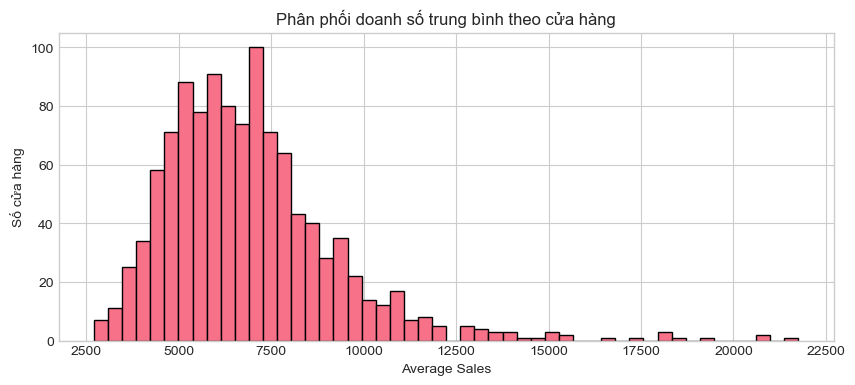

In [1101]:
# Tính doanh số trung bình (chỉ ngày mở cửa)
avg_sales_per_store = df.groupby('Store')['Sales'].mean().sort_values()

# Xem phân phối
plt.figure(figsize=(10,4))
plt.hist(avg_sales_per_store, bins=50, edgecolor='black')
plt.title('Phân phối doanh số trung bình theo cửa hàng')
plt.xlabel('Average Sales')
plt.ylabel('Số cửa hàng')
plt.show()

# Xác định ngưỡng cao và thấp (ví dụ: top 10% và bottom 10%)
low_threshold = avg_sales_per_store.quantile(0.1)
high_threshold = avg_sales_per_store.quantile(0.9)

low_stores = avg_sales_per_store[avg_sales_per_store <= low_threshold].index
high_stores = avg_sales_per_store[avg_sales_per_store >= high_threshold].index


**Phân phối Sales: Giúp nhận ra tính lệch (skewness) – rất quan trọng để quyết định có log‑transform hay không**

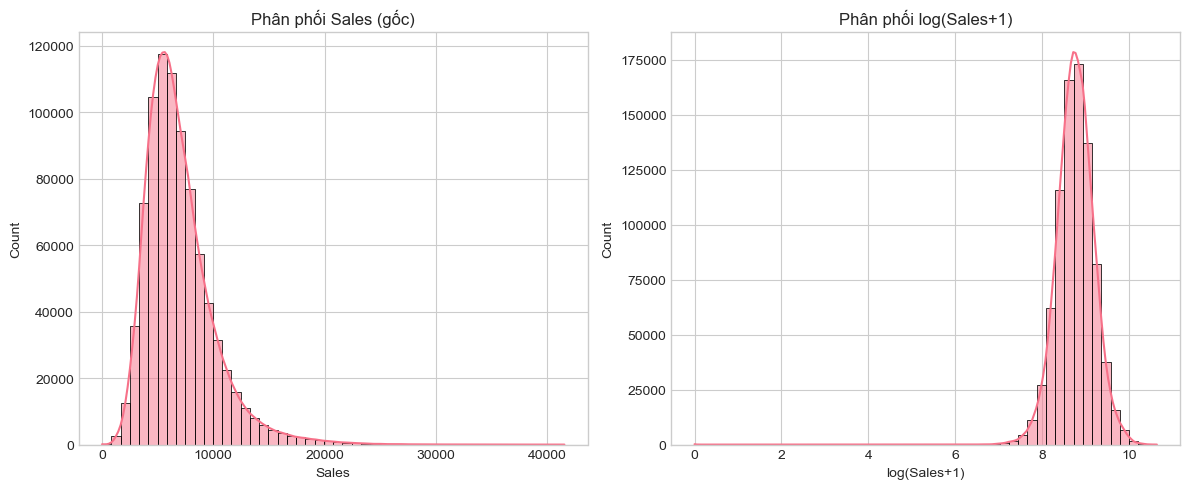

count    844392.000000
mean       6955.514291
std        3104.214680
min           0.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64


In [1104]:
# 1a. Histogram của Sales
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title('Phân phối Sales (gốc)')
plt.xlabel('Sales')

plt.subplot(1,2,2)
sns.histplot(np.log1p(df['Sales']), bins=50, kde=True)
plt.title('Phân phối log(Sales+1)')
plt.xlabel('log(Sales+1)')

plt.tight_layout()
plt.show()

# 1b. Thống kê mô tả
print(df['Sales'].describe())

**Sau khi biến đổi log, phân phối trở nên gần với phân phối chuẩn hơn rõ rệt: đối xứng, một đỉnh rõ, phương sai ổn định hơn**

Số ngày đóng cửa: 0 / 844392 (0.00%)


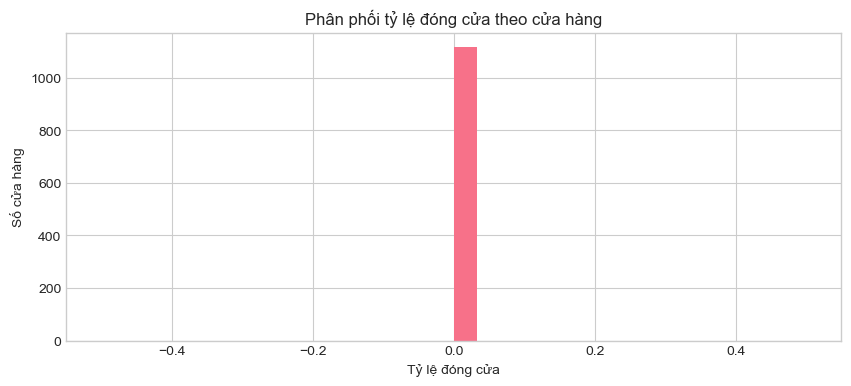

In [1107]:
# Đếm số ngày đóng cửa (Open == 0)
closed_days = df[df['Open'] == 0].shape[0]
total_days = df.shape[0]
closed_percent = closed_days / total_days * 100

print(f"Số ngày đóng cửa: {closed_days} / {total_days} ({closed_percent:.2f}%)")

# (Tuỳ chọn) Xem tỷ lệ đóng cửa theo từng cửa hàng
closed_by_store = df.groupby('Store')['Open'].apply(lambda x: (x==0).mean()).sort_values()
plt.figure(figsize=(10,4))
closed_by_store.hist(bins=30)
plt.title('Phân phối tỷ lệ đóng cửa theo cửa hàng')
plt.xlabel('Tỷ lệ đóng cửa')
plt.ylabel('Số cửa hàng')
plt.show()

              mean  median   count
Promo                             
0      5929.407603  5459.0  467496
1      8228.281239  7649.0  376896


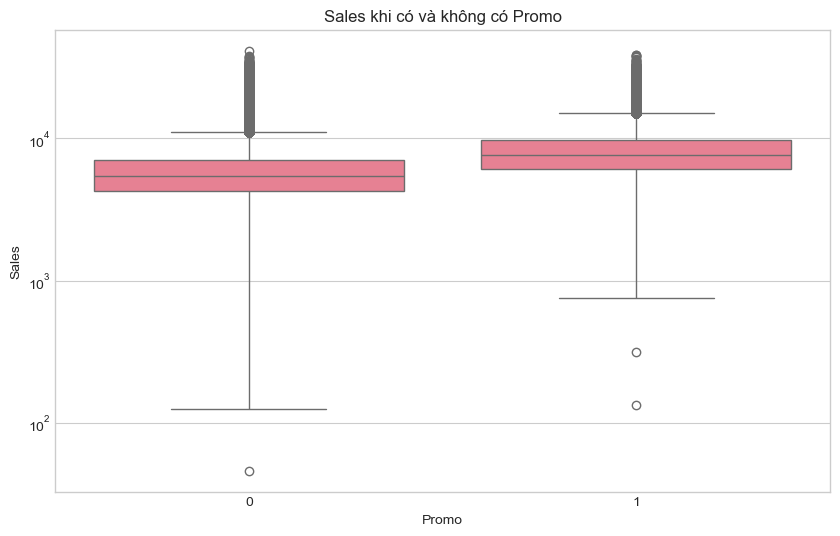

In [1109]:
# So sánh Sales trung bình khi có / không có Promo
promo_stats = df.groupby('Promo')['Sales'].agg(['mean', 'median', 'count'])
print(promo_stats)

# Vẽ boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Promo', y='Sales')
plt.yscale('log')   # vì Sales lệch, dùng log để nhìn rõ hơn
plt.title('Sales khi có và không có Promo')
plt.show()

**Ảnh hưởng của Promo: Khẳng định Promo là feature cực kỳ mạnh – cần giữ lại và có thể tạo thêm tương tác.**

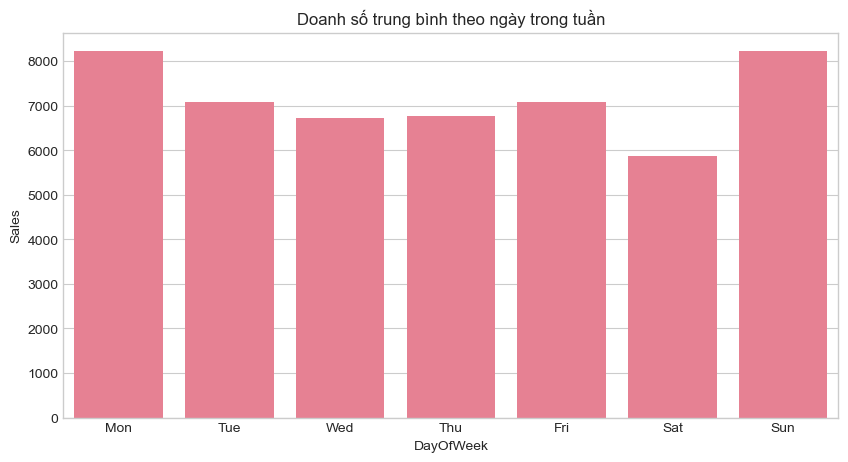

In [1112]:
# Tính trung bình Sales theo DayOfWeek (1 = Thứ Hai, 7 = Chủ Nhật)
weekly_sales = df.groupby('DayOfWeek')['Sales'].mean().reset_index()
weekly_sales['DayOfWeek'] = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(10,5))
sns.barplot(data=weekly_sales, x='DayOfWeek', y='Sales')
plt.title('Doanh số trung bình theo ngày trong tuần')
plt.show()

<Axes: xlabel='DayOfWeek', ylabel='Sales'>

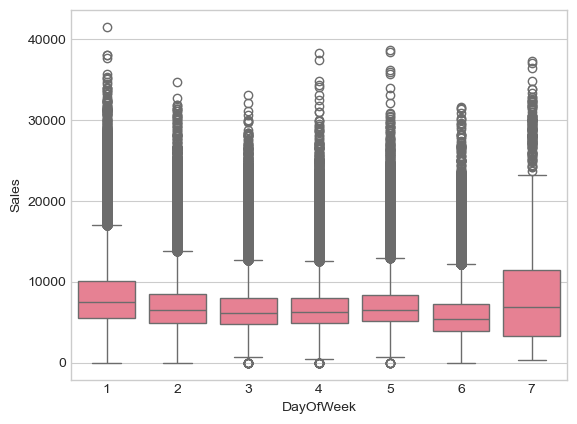

In [1114]:
sns.boxplot(x='DayOfWeek', y='Sales', data=df)

**Doanh số trung bình theo ngày trong tuần: Cho thấy rõ tính mùa vụ tuần – cơ sở để tạo lag 7 và cyclic encoding.**

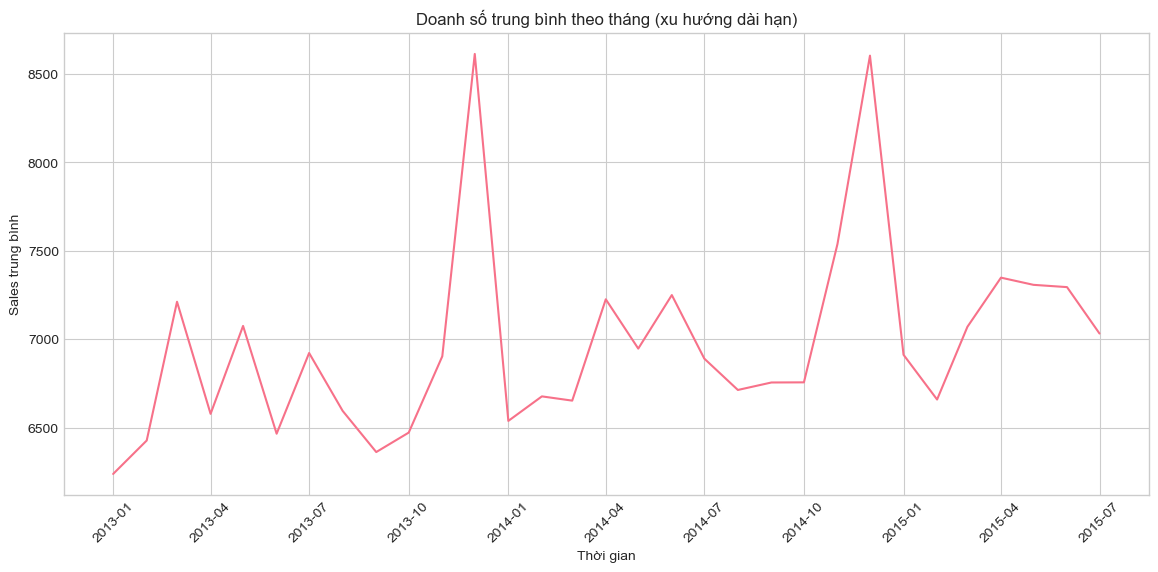

In [1117]:
# Tính trung bình Sales theo tháng (qua tất cả các năm)
df['YearMonth'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['Sales'].mean().reset_index()
monthly_sales['Date'] = monthly_sales['YearMonth'].dt.to_timestamp()

plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_sales, x='Date', y='Sales')
plt.title('Doanh số trung bình theo tháng (xu hướng dài hạn)')
plt.xlabel('Thời gian')
plt.ylabel('Sales trung bình')
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Date'>

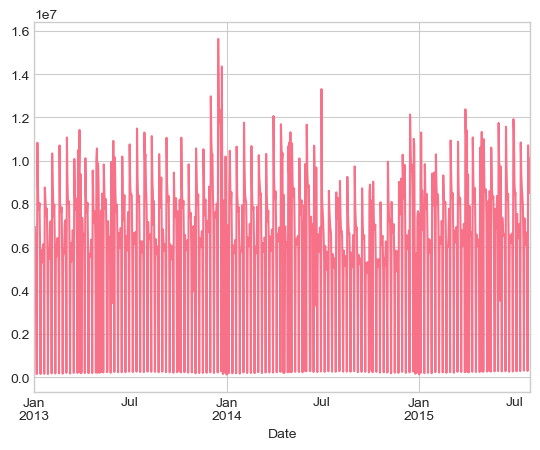

In [1119]:
df.groupby('Date')['Sales'].sum().plot()

 **Xu hướng theo tháng: Bước đầu phát hiện seasonality năm – giúp ích cho cả Prophet và XGBoost.**

## EDA theo Store

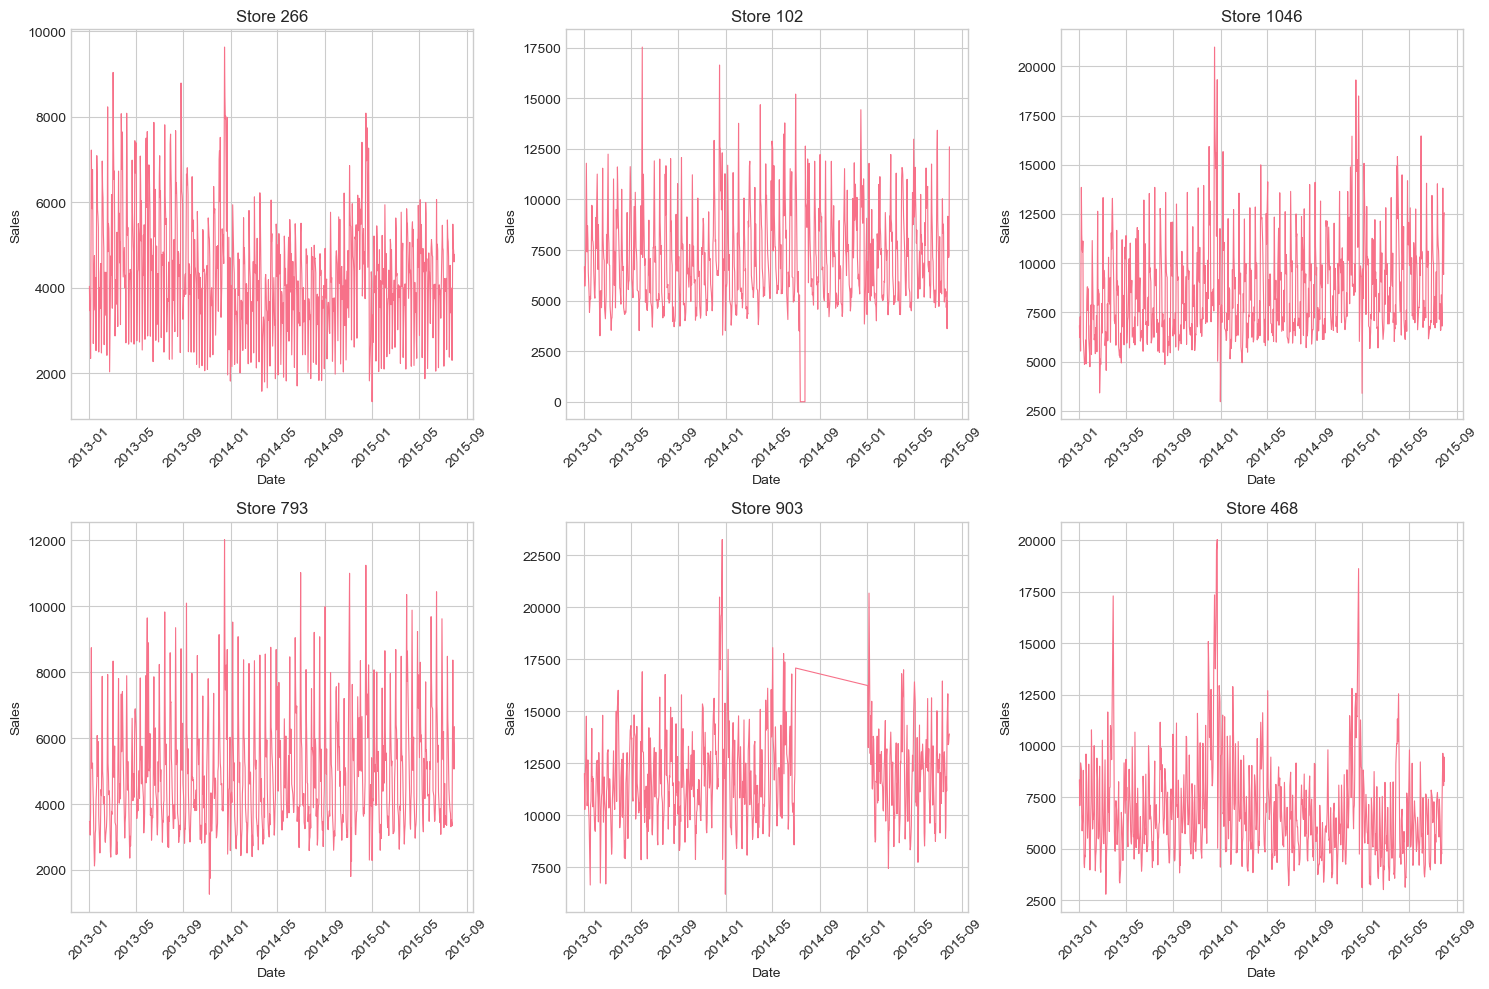

In [1123]:
df_open = df[df['Open'] == 1].copy()

# Chọn 6 store ngẫu nhiên (hoặc theo StoreType)
stores_to_plot = np.random.choice(df_open['Store'].unique(), size=6, replace=False)
# Hoặc có thể chọn theo StoreType:
# stores_to_plot = df_open.groupby('StoreType')['Store'].first().values

plt.figure(figsize=(15, 10))
for i, store in enumerate(stores_to_plot, 1):
    plt.subplot(2, 3, i)
    store_data = df_open[df_open['Store'] == store].sort_values('Date')
    plt.plot(store_data['Date'], store_data['Sales'], linewidth=0.8)
    plt.title(f'Store {store}')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

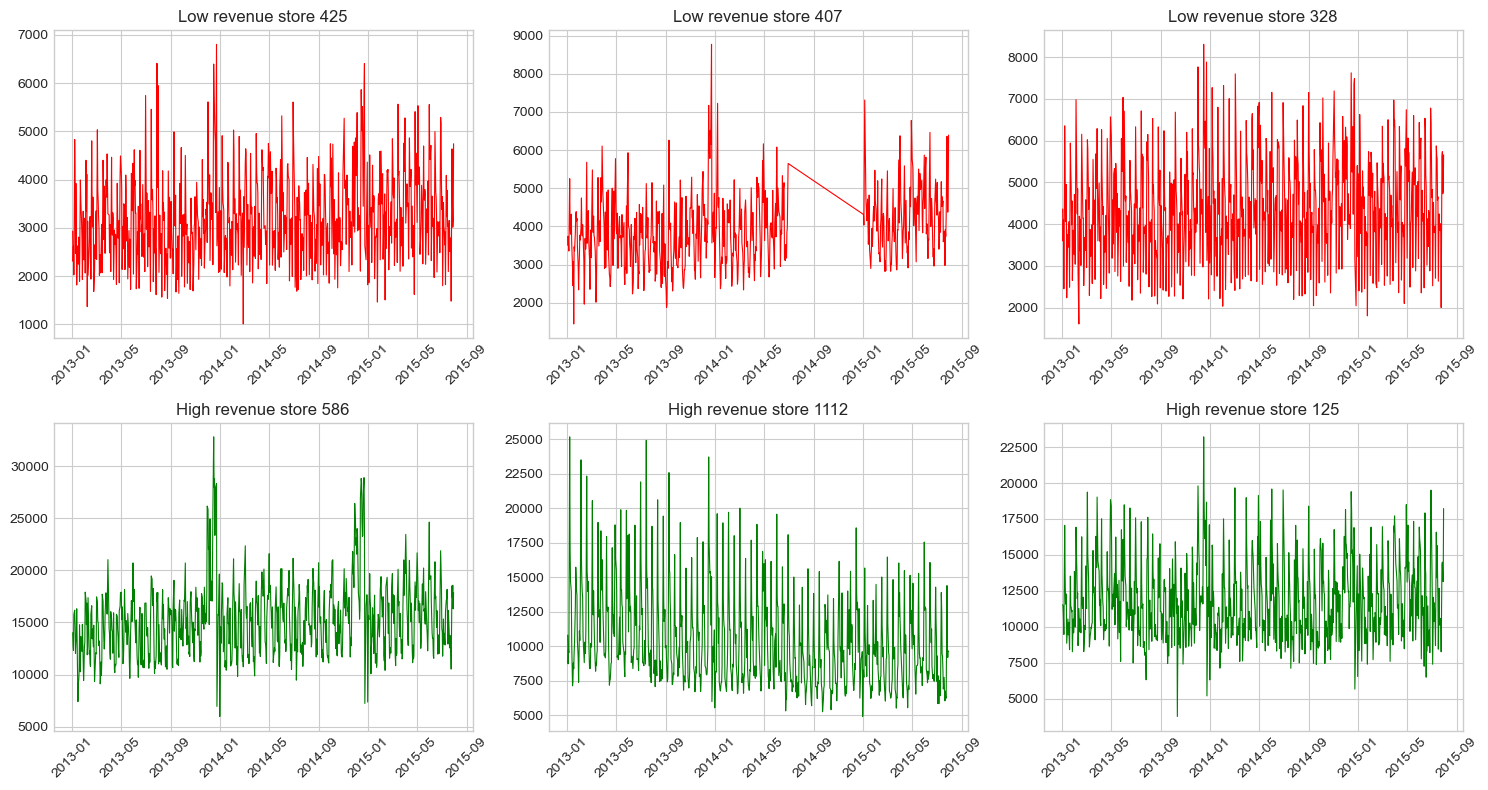

In [1125]:
plt.figure(figsize=(15, 8))

# Vẽ 3 store low revenue
for i, store in enumerate(np.random.choice(low_stores, size=3, replace=False), 1):
    plt.subplot(2, 3, i)
    store_data = df_open[df_open['Store'] == store].sort_values('Date')
    plt.plot(store_data['Date'], store_data['Sales'], linewidth=0.8, color='red')
    plt.title(f'Low revenue store {store}')
    plt.xticks(rotation=45)

# Vẽ 3 store high revenue
for i, store in enumerate(np.random.choice(high_stores, size=3, replace=False), 4):
    plt.subplot(2, 3, i)
    store_data = df_open[df_open['Store'] == store].sort_values('Date')
    plt.plot(store_data['Date'], store_data['Sales'], linewidth=0.8, color='green')
    plt.title(f'High revenue store {store}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

      Store  Sales_mean  Sales_std  Sales_count  Date_<lambda> StoreType  \
816     817    21757.48    4674.80          784            940         a   
261     262    20718.52    4668.88          942            941         b   
1113   1114    20666.56    3452.94          784            940         a   
250     251    19123.07    3547.64          779            940         a   
841     842    18574.80    3788.99          622            940         d   
512     513    18179.09    3284.60          784            940         a   
561     562    17969.56    2931.93          942            941         b   
787     788    17961.91    3150.65          784            940         a   
382     383    17294.72    2785.81          780            940         a   
755     756    16574.82    3912.56          779            940         a   

     Assortment  
816           a  
261           a  
1113          c  
250           c  
841           c  
512           a  
561           c  
787           c  
3

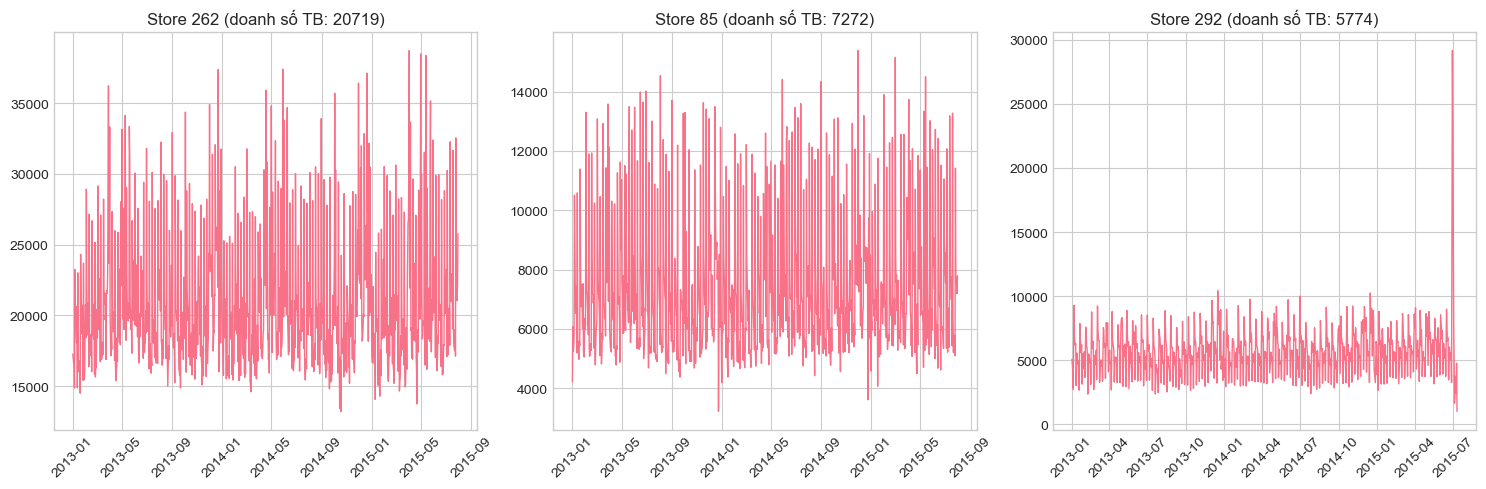

In [1127]:
# Lấy thông tin bổ sung từ store (nếu chưa có trong df, bạn có thể merge lại)
store_info = df[['Store', 'StoreType', 'Assortment']].drop_duplicates()

# Tính các chỉ số cho từng store
store_stats = df_open.groupby('Store').agg({
    'Sales': ['mean', 'std', 'count'],
    'Date': lambda x: (x.max() - x.min()).days
}).round(2)
store_stats.columns = ['_'.join(col).strip() for col in store_stats.columns.values]
store_stats = store_stats.reset_index()

# Merge với store_info
store_stats = store_stats.merge(store_info, on='Store', how='left')

# Xem top/bottom
print(store_stats.sort_values('Sales_mean', ascending=False).head(10))
print(store_stats.sort_values('Sales_mean', ascending=True).head(10))

# Lọc các store có đủ dữ liệu (ví dụ: trên 500 ngày)
store_stats = store_stats[store_stats['Date_<lambda>'] > 500]

# Chọn thủ công 3 store dựa trên quan sát
# Ví dụ:
candidates = {
    'high': 262,   # store có doanh số cao nhất nhì
    'mid':  85,    # store có doanh số trung bình
    'low':  292    # store có doanh số thấp nhưng vẫn có dữ liệu tốt
}
selected_stores = list(candidates.values())

# Vẽ lại 3 store này để chắc chắn
plt.figure(figsize=(15, 5))
for i, store in enumerate(selected_stores, 1):
    plt.subplot(1, 3, i)
    store_data = df_open[df_open['Store'] == store].sort_values('Date')
    plt.plot(store_data['Date'], store_data['Sales'], linewidth=1)
    plt.title(f'Store {store} (doanh số TB: {store_data["Sales"].mean():.0f})')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [1129]:
# Tìm store doanh số thấp nhưng ít biến động (std nhỏ)
low_volatility_stores = df_open.groupby('Store')['Sales'].agg(['mean', 'std']).reset_index()
low_volatility_stores = low_volatility_stores[low_volatility_stores['mean'] < 7000]
low_volatility_stores = low_volatility_stores.sort_values('std')
print(low_volatility_stores.head(10))

     Store         mean         std
793    794  3083.812821  575.952359
788    789  3380.011583  630.273422
655    656  3245.192061  690.298439
207    208  2936.290816  716.525610
557    558  3241.524235  720.092654
922    923  5315.344388  740.820693
236    237  4535.991071  759.034330
641    642  3652.709884  786.538623
259    260  6559.997449  809.612179
218    219  3133.712452  822.266544


## EDA Corr

Correlation Matrix:
                   Sales  Sales_Lag7  Sales_Rolling7
Sales           1.000000    0.515872        0.712776
Sales_Lag7      0.515872    1.000000        0.825798
Sales_Rolling7  0.712776    0.825798        1.000000


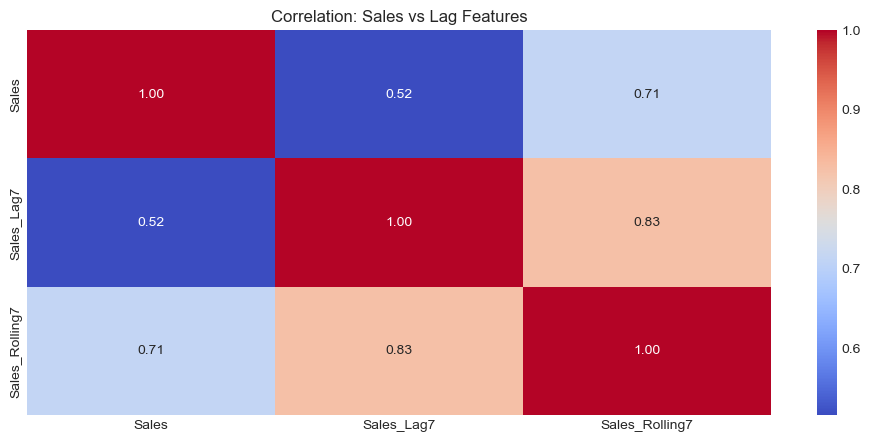

In [1132]:
corr_df = df[['Sales', 'Sales_Lag7', 'Sales_Rolling7']].dropna()

# Tính correlation
corr_matrix = corr_df.corr()

print("Correlation Matrix:")
print(corr_matrix)

# Heatmap
plt.figure(figsize=(12,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation: Sales vs Lag Features")
plt.show()

**Nhận xét:**

**Sales tương quan 0.71 với Rolling7 – rất cao, cho thấy trung bình động 7 ngày là một dự báo tốt cho doanh số hiện tại.**

**Sales tương quan 0.52 với Lag7 – cũng khá, nhưng thấp hơn Rolling7.**

**Tương quan giữa Lag7 và Rolling7 là 0.83 – xác nhận lại đa cộng tuyến.**

**Kết luận:**
**Cả hai đều là những feature mạnh.**

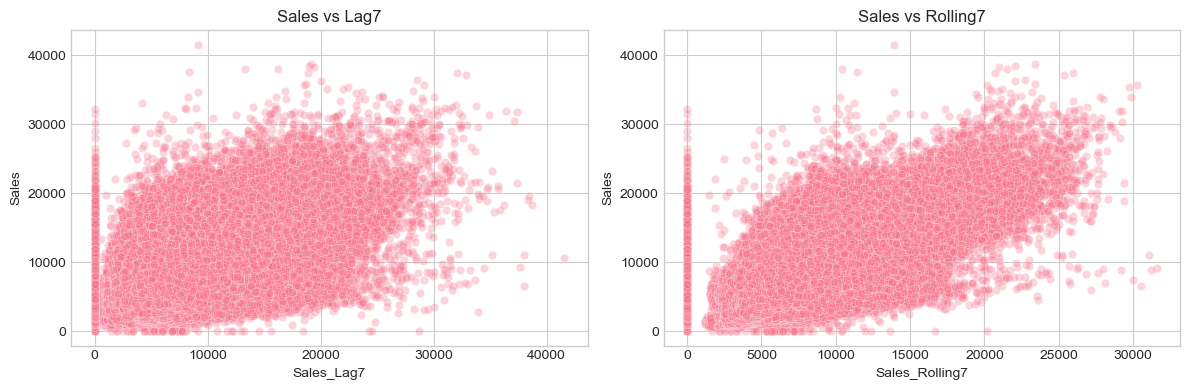

In [1135]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.scatterplot(x='Sales_Lag7', y='Sales', data=corr_df, alpha=0.3)
plt.title("Sales vs Lag7")

plt.subplot(1,2,2)
sns.scatterplot(x='Sales_Rolling7', y='Sales', data=corr_df, alpha=0.3)
plt.title("Sales vs Rolling7")

plt.tight_layout()
plt.show()

**Lag7 và Rolling7 bám sát xu hướng của Sales, đặc biệt Rolling7 mượt hơn và ít nhiễu**

In [1138]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Chọn feature cho Linear Regression
features = [
    'Sales_Lag7',
    'Sales_Rolling7',
    'Sales_Rolling30',
    'Promo_Rolling7'
]

X = df[features].dropna()
X = add_constant(X)

vif_df = pd.DataFrame()
vif_df["Feature"] = X.columns
vif_df["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_df)

           Feature       VIF
0            const  9.439857
1       Sales_Lag7  3.174020
2   Sales_Rolling7  6.663942
3  Sales_Rolling30  4.484165
4   Promo_Rolling7  1.169217


**Sales_Rolling7 được tính từ trung bình của 7 ngày gần nhất, trong đó bao gồm cả Sales_Lag7. Vì vậy, hai feature này có tương quan cao (bạn thấy ở correlation matrix: 0.83), dẫn đến VIF của Rolling7 tăng cao -> LinearRegession sẽ dùng Ridge**

# ***Data Preprosessing vs ML***

## Baseline Model - Linear Regression ( Ridge Method)

### Processing

In [1144]:
df["Sales_Lag7"]

0            0.0
1            0.0
2            0.0
3            0.0
4            0.0
           ...  
844387    7264.0
844388    6083.0
844389    5074.0
844390    5342.0
844391    6150.0
Name: Sales_Lag7, Length: 844392, dtype: float64

In [1146]:
df_baseline = df.copy()

**Seasonal Lag**

In [1149]:
df_baseline = df_baseline.sort_values(['Store','Date'])

df_baseline['lag_56'] = df_baseline.groupby('Store')['Sales'].shift(56)
df_baseline['lag_365'] = df_baseline.groupby('Store')['Sales'].shift(365)

**Trend Feature**

In [1152]:
df_baseline['trend_8w'] = df_baseline['Sales'] - df_baseline['lag_56']
df_baseline['trend_yoy'] = df_baseline['Sales'] - df_baseline['lag_365']

**Log transform target**

In [1155]:
df_baseline['log_sales'] = np.log1p(df_baseline['Sales'])

**Chọn Feature**

In [1158]:
features_num = [
    'lag_56',
    'lag_365',
    'trend_8w',
    'trend_yoy',
    'CompetitionDistance',
    'Promo',
    'SchoolHoliday'
]

features_cat = [
    'DayOfWeek',
    'StoreType',
    'Assortment',
    'StateHoliday'
]

target = 'log_sales'

**Drop NA**

In [1161]:
df_baseline = df_baseline.dropna(subset=['lag_56','lag_365'])

In [1163]:
train[features_num + features_cat].isna().sum().sort_values(ascending=False)

KeyError: "['lag_56', 'lag_365', 'trend_8w', 'trend_yoy', 'CompetitionDistance', 'StoreType', 'Assortment'] not in index"

**->CompetitionDistance còn có missing**

In [1166]:
df_baseline['CompetitionDistance'] = df_baseline['CompetitionDistance'].fillna(
    df_baseline['CompetitionDistance'].median()
)

In [1168]:
# Kiểm tra missing trên df_baseline
print(df_baseline[['CompetitionDistance']].isna().sum())

CompetitionDistance    0
dtype: int64


### Traning

**Time-based split**

In [1172]:
split_date = '2015-06-15'

train = df_baseline[df_baseline['Date'] < split_date]
valid = df_baseline[df_baseline['Date'] >= split_date]

**Encoding categorical( One Hot Encoding)**

In [1175]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [1177]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
    ]
)

**Train Ridge Regression**

In [1180]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

ridge_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', Ridge(alpha=1.0))
])

ridge_model.fit(train[features_num + features_cat], train[target])

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['lag_56', 'lag_365',
                                                   'trend_8w', 'trend_yoy',
                                                   'CompetitionDistance',
                                                   'Promo', 'SchoolHoliday']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['DayOfWeek', 'StoreType',
                                                   'Assortment',
                                                   'StateHoliday'])])),
                ('model', Ridge())])

**Predict validation**

In [1183]:
pred_log = ridge_model.predict(valid[features_num + features_cat])

pred_sales = np.expm1(pred_log)

**Đánh giá = RMSPE**

In [1186]:
def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2))

score = rmspe(valid['Sales'], pred_sales)

print("Validation RMSPE:", score)

Validation RMSPE: 0.16391045459761092


### Kiểm tra và đánh giá

**Kiểm tra có Overfit không khi RMSPE rất khả quan**

In [1190]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Giả sử features_num là list các cột số, features_cat là list cột phân loại
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features_num),
        ('cat', categorical_transformer, features_cat)
    ])

ridge_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', Ridge(alpha=1.0))
])

ridge_model.fit(train[features_num + features_cat], train[target])

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['lag_56', 'lag_365',
                                                   'trend_8w', 'trend_yoy',
                                                   'CompetitionDistance',
                                                   'Promo', 'SchoolHoliday']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['DayOfWeek', 'StoreType',
                                                   'Assortment',
                                                   'StateHoliday'])])),
                ('model', Ridge())])

In [1191]:
train_pred_log = ridge_model.predict(train[features_num + features_cat])
train_pred = np.expm1(train_pred_log)

train_score = rmspe(train['Sales'], train_pred)

print("Train RMSPE:", train_score)
print("Validation RMSPE:", score)

Train RMSPE: inf
Validation RMSPE: 0.16391045459761092


**Đang gặp lỗi**

In [1195]:
(train['Sales'] == 0).sum()

27

In [1197]:
def rmspe(y_true, y_pred):
    mask = y_true > 0
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

In [1199]:
train_score = rmspe(train['Sales'], train_pred)
print("Train RMSPE:", train_score)
print("Validation RMSPE:", score)

Train RMSPE: 0.1879858450167431
Validation RMSPE: 0.16391045459761092


**Model có vẻ vẫn ổn định, chưa overfit**

In [1202]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

tscv = TimeSeriesSplit(n_splits=3)
cv_scores = []

for train_idx, val_idx in tscv.split(df_baseline):
    train_fold = df_baseline.iloc[train_idx]
    val_fold = df_baseline.iloc[val_idx]
    
    ridge_model.fit(train_fold[features_num + features_cat], train_fold[target])
    pred_val_log = ridge_model.predict(val_fold[features_num + features_cat])
    pred_val = np.expm1(pred_val_log)
    score = rmspe(val_fold['Sales'], pred_val)
    cv_scores.append(score)

print("CV scores:", cv_scores)
print("Mean CV RMSPE:", np.mean(cv_scores))

CV scores: [0.15743366535683684, 0.240308524548338, 0.17045921514782042]
Mean CV RMSPE: 0.18940046835099844


In [1203]:
feature_names = ridge_model.named_steps['preprocess'].get_feature_names_out()

coef = ridge_model.named_steps['model'].coef_

importance = pd.Series(coef, index=feature_names).sort_values(key=abs, ascending=False)

importance.head(15)

num__lag_365           0.199074
num__lag_56            0.198159
num__trend_yoy         0.176470
num__trend_8w          0.174095
cat__DayOfWeek_7      -0.124779
cat__StateHoliday_b   -0.106559
cat__StateHoliday_0    0.105777
cat__StoreType_b      -0.078166
cat__Assortment_b      0.068891
cat__StoreType_d       0.043542
cat__Assortment_a     -0.042448
cat__DayOfWeek_5       0.038700
cat__StateHoliday_c    0.035815
cat__StateHoliday_a   -0.035033
cat__DayOfWeek_2       0.028009
dtype: float64

**Nhận xét**

Lag feature đang thống trị model
lag_365
lag_56
Điều này rất hợp lý vì retail có:
strong weekly pattern
strong yearly pattern
Trend feature cũng hoạt động tốt
trend_yoy
trend_8w
Nghĩa là model bắt được direction của store growth
Sunday thường
sales drop
store closed
Nên weight lớn.

## Deep-Dive Model - Prophet

### Xử lí chọn Store

1. Store doanh thu cao nhất
2. tore doanh thu thấp nhất
3. Store biến động mạnh nhất

In [1211]:
store_stats = (
    df_baseline.groupby('Store')['Sales']
    .agg(['mean','std'])
)

store_stats['cv'] = store_stats['std'] / store_stats['mean']

In [1213]:
store_high = store_stats['mean'].idxmax()

In [1215]:
store_low = store_stats['mean'].idxmin()

In [1217]:
store_volatile = store_stats['cv'].idxmax()

In [1219]:
print(store_high, store_low, store_volatile)

1114 307 198


In [1221]:
stores_of_interest = [store_high, store_low, store_volatile]

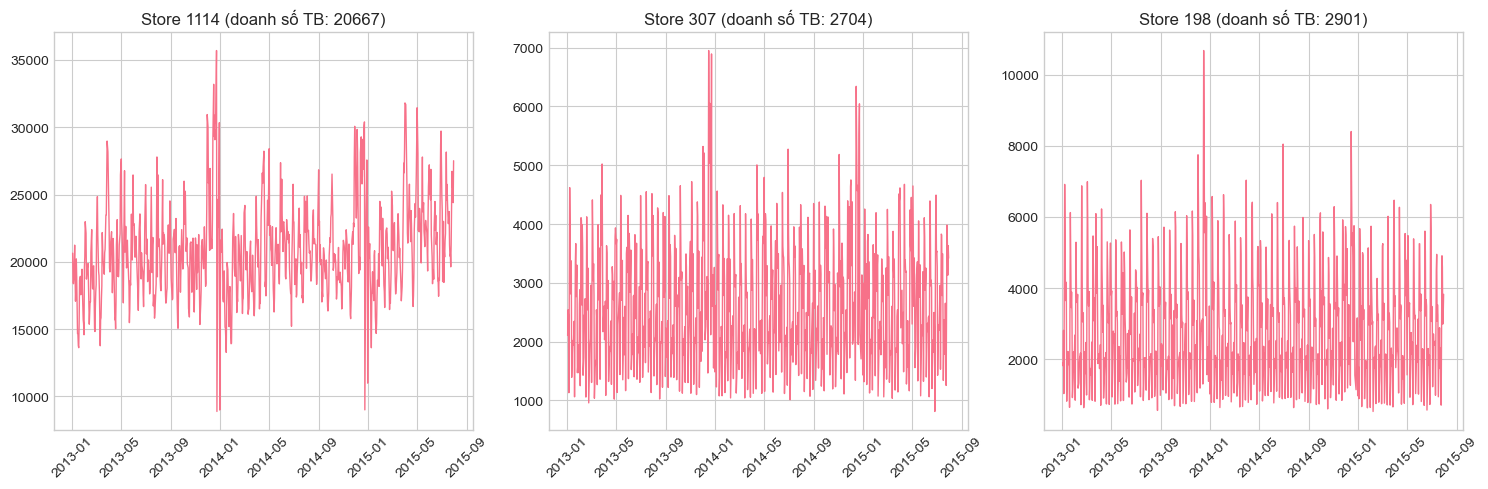

In [1223]:
plt.figure(figsize=(15, 5))
for i, store in enumerate(stores_of_interest, 1):
    plt.subplot(1, 3, i)
    store_data = df[df['Store'] == store].sort_values('Date')
    plt.plot(store_data['Date'], store_data['Sales'], linewidth=1)
    plt.title(f'Store {store} (doanh số TB: {store_data["Sales"].mean():.0f})')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Training

**Dự báo = Xu hướng + Mùa vụ tuần + Mùa vụ năm + Tác động của Khuyến mãi (Promo)**

In [1227]:
def prepare_prophet_data(df, store_id):
    
    store_df = df[df['Store'] == store_id].copy()
    
    prophet_df = store_df[['Date','Sales','Promo']].rename(
        columns={
            'Date':'ds',
            'Sales':'y'
        }
    )
    
    return prophet_df

In [1229]:
from prophet import Prophet

df_prophet = prepare_prophet_data(df_baseline, store_high)

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.add_regressor('Promo')

model.fit(df_prophet)

00:00:09 - cmdstanpy - INFO - Chain [1] start processing
00:00:09 - cmdstanpy - INFO - Chain [1] done processing


In [1231]:
future = model.make_future_dataframe(periods=0)

future = future.merge(
    df_prophet[['ds','Promo']],
    on='ds',
    how='left'
)

future['Promo'] = future['Promo'].fillna(0)

forecast = model.predict(future)

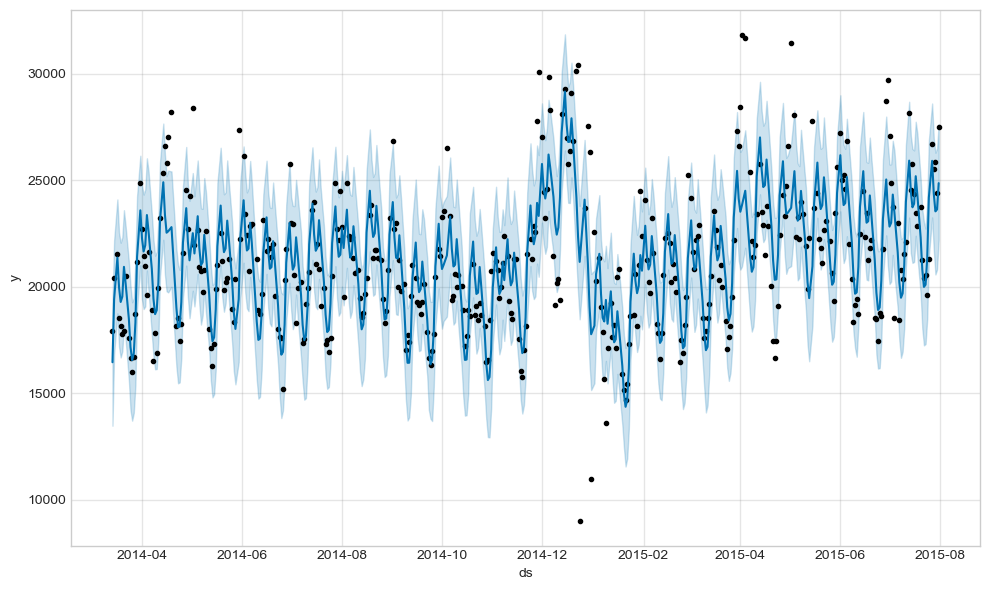

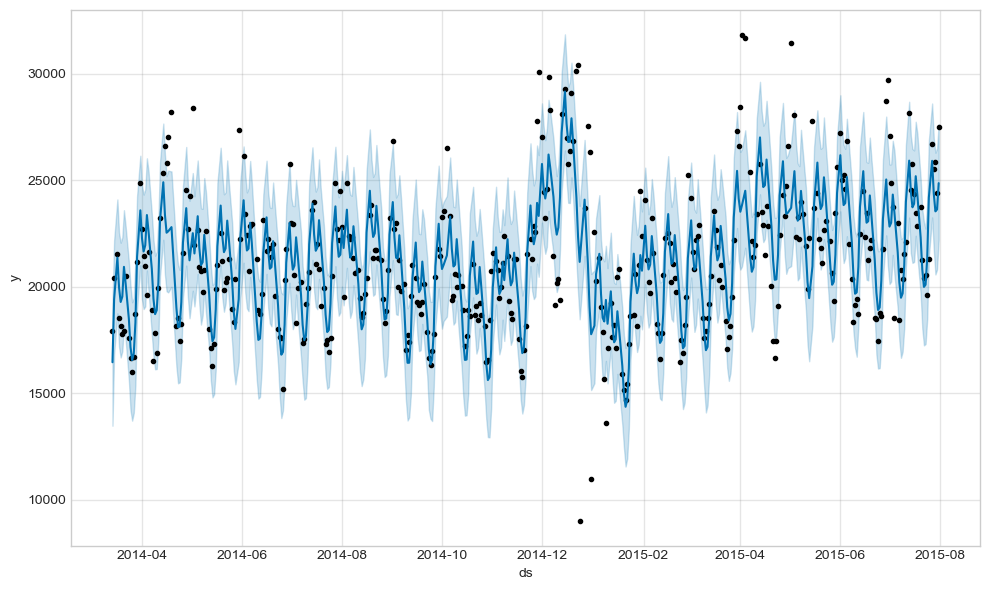

In [1233]:
model.plot(forecast)

**Đánh giá**
Tác động của sự kiện ngoài: Ta thêm một biến phụ là Promo (Khuyến mãi) vào mô hình. Do đó, đường màu xanh đậm đã cộng gộp cả sức ảnh hưởng của các đợt khuyến mãi. Có thể thấy những đoạn đường dự báo nhô lên đột biến (như khoảng tháng 12/2014), rất có thể là do tác động của đợt Promo.

Tính mùa vụ (Seasonality): Đường màu xanh có các nhịp dao động lên xuống rất đều đặn, cho thấy dữ liệu có tính chu kỳ (có thể là chu kỳ theo tuần, ví dụ cuối tuần cao, giữa tuần thấp).

Đánh giá mô hình: Nhìn chung, mô hình đang khớp khá tốt với thực tế vì phần lớn các chấm đen đều bám sát đường màu xanh và nằm gọn trong vùng xanh nhạt. **Tuy nhiên, có một vài điểm bất thường (outliers) rơi xuống rất thấp**, văng hẳn ra khỏi vùng xanh nhạt vào khoảng tháng 1/2015. Đây có thể là những ngày xảy ra sự cố lỗi hệ thống, nghỉ lễ đặc biệt, hoặc thiếu dữ liệu.

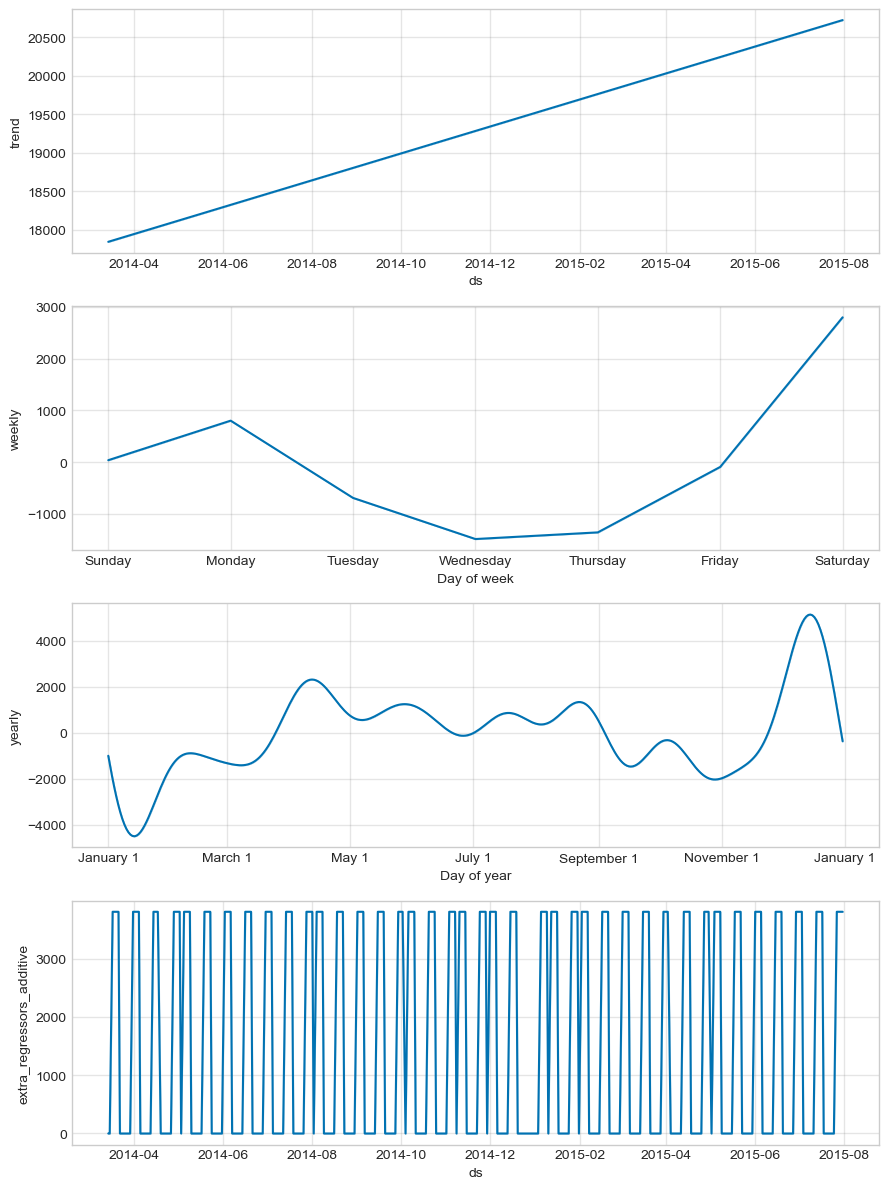

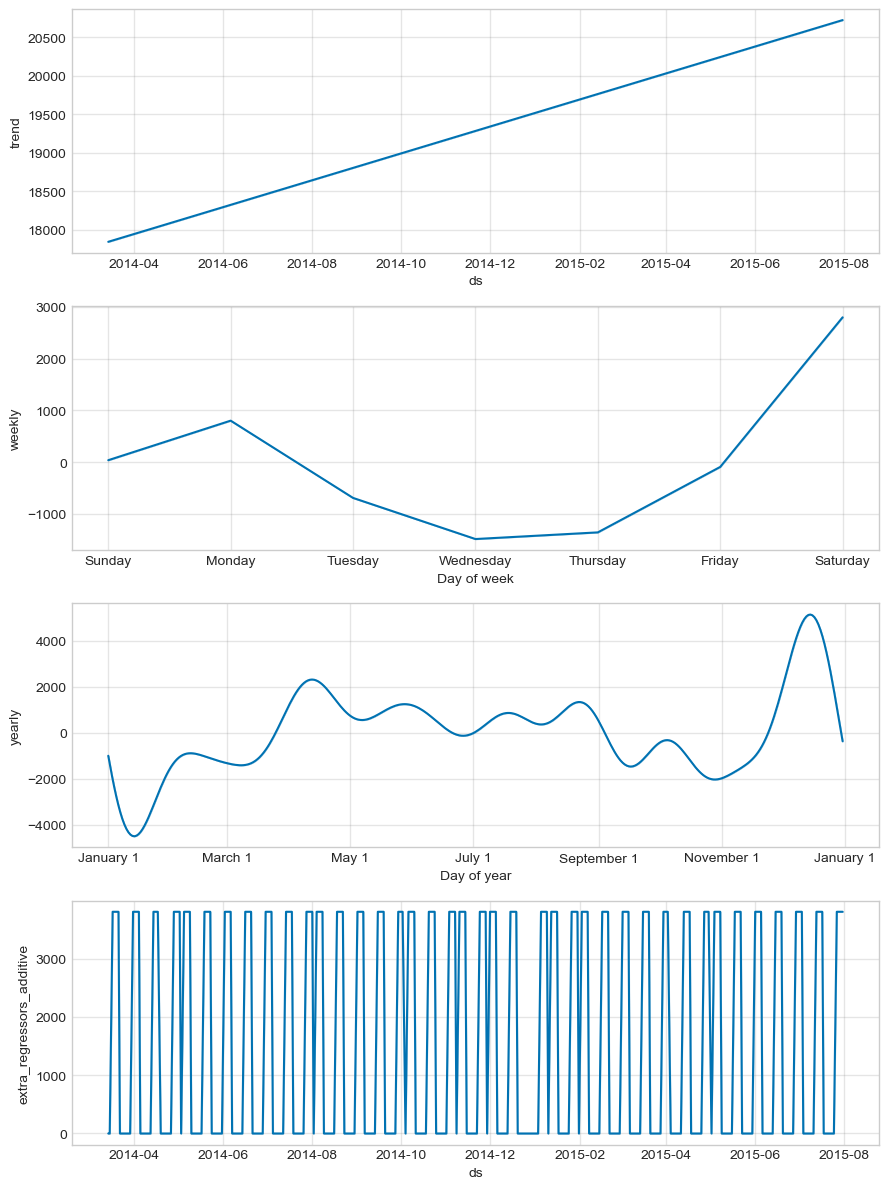

In [1236]:
model.plot_components(forecast)

**Xu hướng (Trend)**

Ý nghĩa: Thể hiện sự tăng trưởng hoặc suy giảm dài hạn của dữ liệu, bỏ qua mọi yếu tố nhiễu hay chu kỳ ngắn hạn.

Phân tích: Đường này đi lên đều đặn thành một đường thẳng từ tháng 4/2014 đến tháng 8/2015. Điều này cho thấy hoạt động kinh doanh (hoặc chỉ số bạn đang đo lường) đang có sự tăng trưởng ổn định và tích cực theo thời gian.

**Mùa vụ theo tuần (Weekly)**

Ý nghĩa: Cho biết mức độ đóng góp (thêm vào hoặc trừ đi) của mỗi ngày trong tuần so với mức trung bình.

Phân tích: * Chỉ số này đạt đỉnh vào Thứ Bảy (Saturday) và cao thứ nhì vào Thứ Hai (Monday).

Ngược lại, dữ liệu chạm đáy (giảm mạnh nhất) vào giữa tuần là Thứ Tư (Wednesday) và Thứ Năm (Thursday).

-> biểu đồ doanh thu bán lẻ, có vẻ khách hàng của bạn thường mua sắm nhiều nhất vào cuối tuần và ngày đầu tuần.

**Mùa vụ theo năm (Yearly)**

Ý nghĩa: Thể hiện chu kỳ dao động trong suốt 1 năm (từ tháng 1 đến tháng 12).

Phân tích: **Có một đỉnh rất cao vào cuối năm** (từ giữa tháng 11 kéo dài đến hết tháng 12). Điều này rất hợp lý với các mùa lễ hội, Black Friday, Giáng Sinh, Tết dương lịch.

Ngay sau đỉnh đó là một đáy rất sâu vào tháng 1 (hiệu ứng sụt giảm sau dịp lễ hội).

Trong năm cũng có một số gợn sóng nhỏ tăng lên vào khoảng cuối tháng 4 - đầu tháng 5 và tháng 9.

**Tác động của biến phụ - Promo**

Ý nghĩa: Đây chính là tác động của biến Promo (Khuyến mãi) mà bạn đã thêm vào ở đoạn code ban đầu.

Phân tích: Nó có hình dạng như các "nhịp xung" (bật/tắt). Khi không có khuyến mãi, giá trị bằng 0. Khi có sự kiện khuyến mãi, mô hình học được rằng sự kiện này sẽ tự động cộng thêm khoảng gần 4000 đơn vị vào dự báo tổng thể. Điều này cho thấy các chương trình khuyến mãi của bạn mang lại hiệu quả gia tăng rất rõ rệt.

### Đánh giá lẻ

00:00:15 - cmdstanpy - INFO - Chain [1] start processing
00:00:15 - cmdstanpy - INFO - Chain [1] done processing


Store 1114


00:00:15 - cmdstanpy - INFO - Chain [1] start processing
00:00:15 - cmdstanpy - INFO - Chain [1] done processing


Store 307


00:00:15 - cmdstanpy - INFO - Chain [1] start processing
00:00:15 - cmdstanpy - INFO - Chain [1] done processing


Store 198


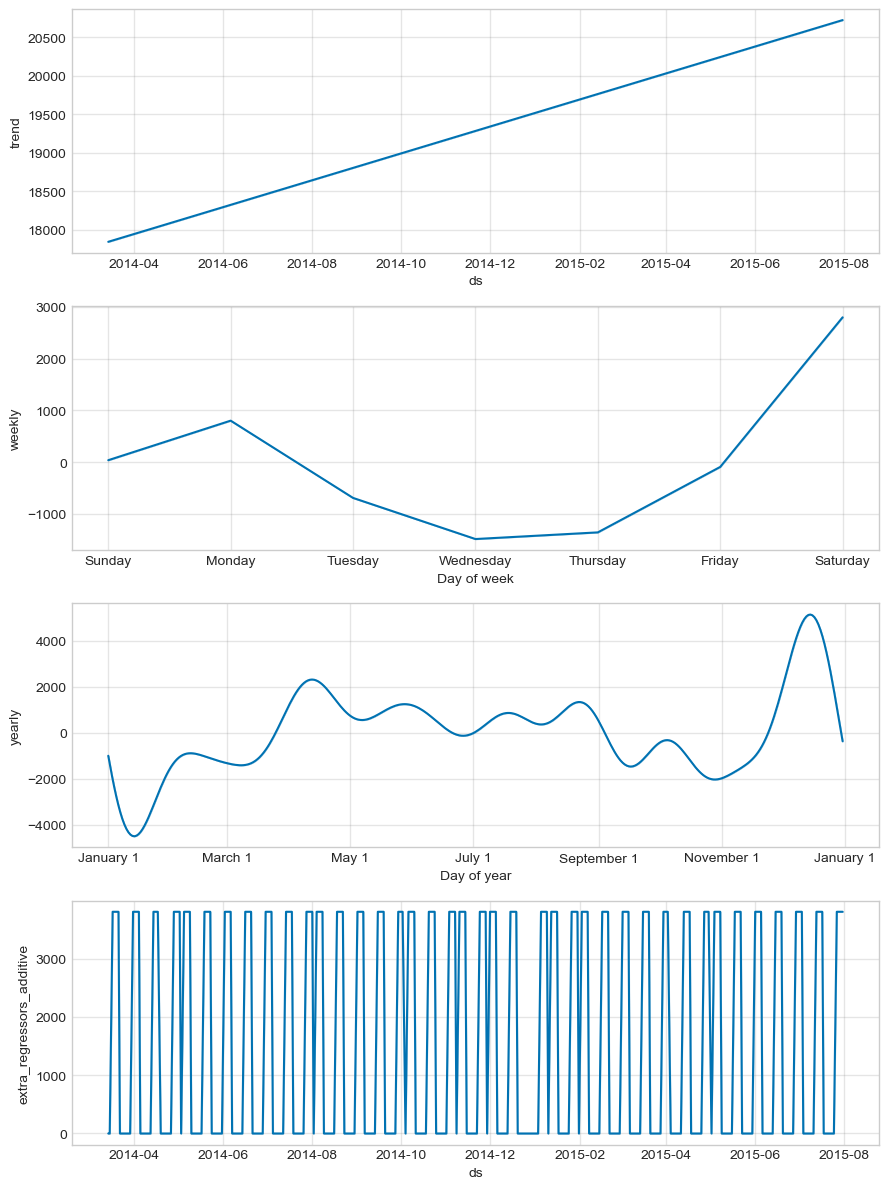

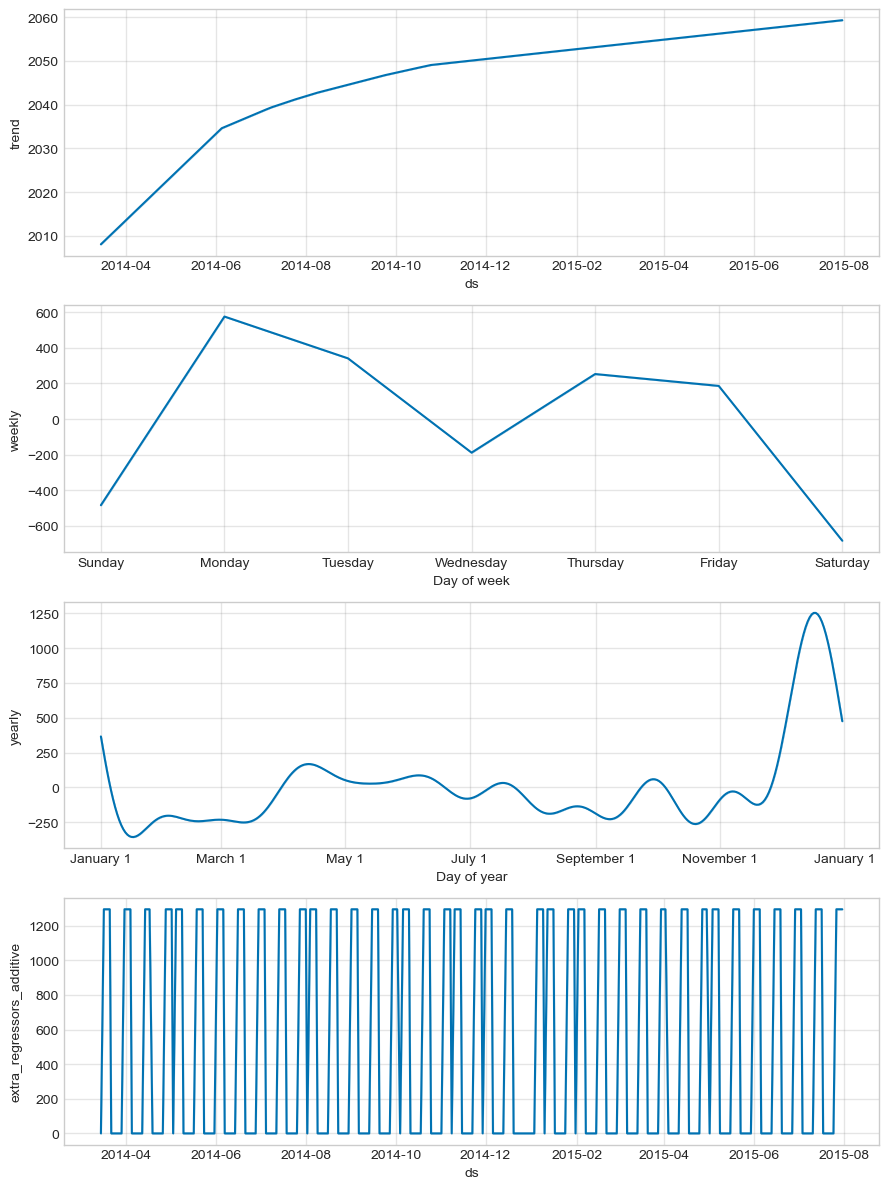

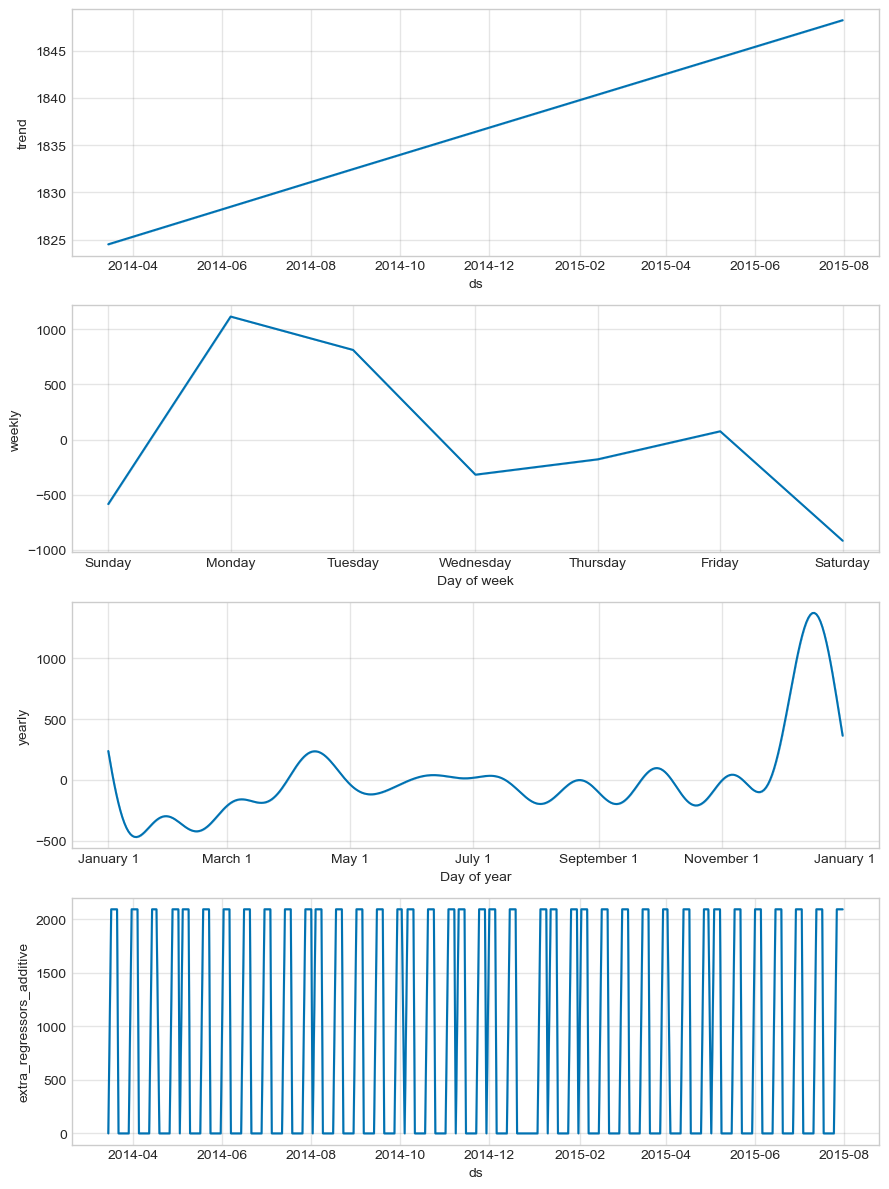

In [1243]:
stores = [store_high, store_low, store_volatile]

for store in stores:

    df_prophet = prepare_prophet_data(df_baseline, store)

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True
    )

    model.add_regressor('Promo')

    model.fit(df_prophet)

    future = model.make_future_dataframe(periods=0)

    future = future.merge(
        df_prophet[['ds','Promo']],
        on='ds',
        how='left'
    )

    future['Promo'] = future['Promo'].fillna(0)

    forecast = model.predict(future)

    print(f"Store {store}")

    model.plot_components(forecast)

**1. Cửa hàng 1 store_high**

Quy mô (Trend): Rất lớn, đường cơ sở từ 18.000 tăng lên hơn 20.000.

Hành vi trong tuần (Weekly): Bán cực kỳ chạy vào Thứ Bảy và Thứ Hai. Giảm sâu vào giữa tuần. Nhịp điệu này giống các cửa hàng ở trung tâm mua sắm hoặc khu vực đông dân cư dịp cuối tuần.

Mùa vụ năm (Yearly): Bùng nổ doanh số vào dịp cuối năm (Tháng 12 - Tháng 1).

Hiệu quả Khuyến mãi (Promo): Rất mạnh, mỗi đợt Promo cộng thêm gần 4000 đơn vị.

**2. Cửa hàng 2  store_low**

Quy mô (Trend): Rất nhỏ, doanh số nền chỉ loanh quanh mốc 2010 - 2060 và có dấu hiệu tăng chậm lại (đường cong đi ngang dần).

Hành vi trong tuần (Weekly): Khác biệt hoàn toàn với cửa hàng 1! Nơi này bán chạy nhất vào Thứ Hai và sụt giảm cực mạnh vào Thứ Bảy, Chủ Nhật. Đây rất có thể là cửa hàng nằm ở khu vực văn phòng/công sở, nơi khách hàng chủ yếu mua sắm vào ngày làm việc.

Mùa vụ năm (Yearly): Vẫn có đỉnh vào cuối năm nhưng biên độ tăng không quá đột biến.

Hiệu quả Khuyến mãi (Promo): Khuyến mãi mang lại khoảng 1300 đơn vị. Tuy con số tuyệt đối nhỏ hơn cửa hàng 1, nhưng so với mức nền ~2000 thì đây là một tỷ lệ tăng trưởng khổng lồ (tăng hơn 50% doanh số).

**3. Cửa hàng 3 store_volatile**

Quy mô (Trend): Mức nền thấp (1825 - 1845) và đang tăng nhẹ.

Hành vi trong tuần (Weekly): Tương tự cửa hàng 2, đạt đỉnh vào Thứ Hai, Thứ Ba và tạo đáy vào cuối tuần. Tuy nhiên, mức độ biến động (volatile) cực kỳ gắt: từ đáy Thứ Bảy lên đỉnh Thứ Hai chênh nhau gần 2000 đơn vị (lớn hơn cả doanh số nền).

Mùa vụ năm (Yearly): Đỉnh cuối năm rất nhọn và biến động thất thường trong năm.

Hiệu quả Khuyến mãi (Promo): Promo tác động cực kỳ dữ dội, đem về hơn 2000 đơn vị mỗi khi kích hoạt. Có vẻ khách hàng ở đây cực kỳ nhạy cảm với giá/khuyến mãi; họ chỉ chờ có Promo để mua hàng.

### Dự đoán

In [1247]:
train = df_prophet[df_prophet['ds'] < split_date]
test  = df_prophet[df_prophet['ds'] >= split_date]

In [1249]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True
)

model.add_regressor("Promo")

model.fit(train)

00:00:19 - cmdstanpy - INFO - Chain [1] start processing
00:00:19 - cmdstanpy - INFO - Chain [1] done processing


In [1251]:
future = model.make_future_dataframe(periods=len(test))

In [1253]:
future = future.merge(
    df_prophet[['ds','Promo']],
    on='ds',
    how='left'
)

future['Promo'] = future['Promo'].fillna(0)

In [1255]:
forecast = model.predict(future)

In [1257]:
pred = forecast[['ds','yhat']]

In [1259]:
eval_df = test.merge(pred, on="ds")

In [1261]:
import numpy as np

def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2))

score = rmspe(eval_df['y'], eval_df['yhat'])

print(score)

0.2587546064065966


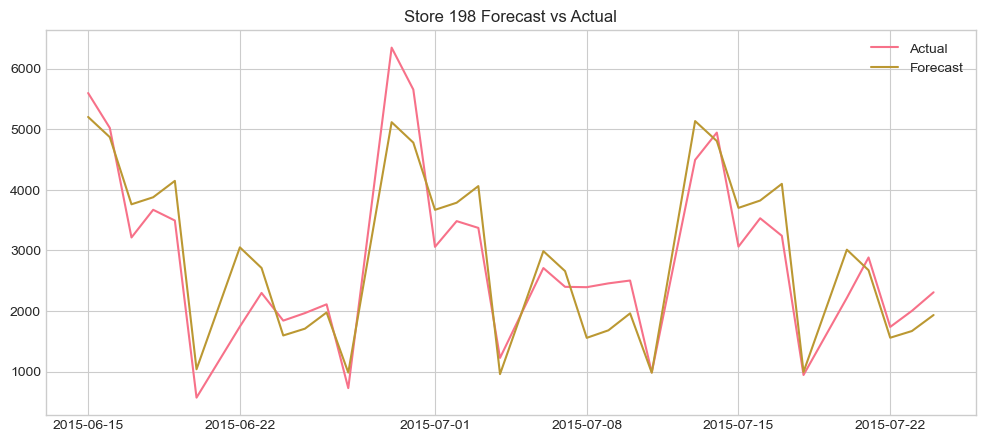

In [1263]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(eval_df['ds'], eval_df['y'], label="Actual")
plt.plot(eval_df['ds'], eval_df['yhat'], label="Forecast")

plt.legend()
plt.title(f"Store {store} Forecast vs Actual")
plt.show()

In [1265]:
stores = [store_high, store_low, store_volatile]

for store in stores:

    df_prophet = prepare_prophet_data(df_baseline, store)

    split_date = "2015-01-01"

    train = df_prophet[df_prophet['ds'] < split_date]
    test  = df_prophet[df_prophet['ds'] >= split_date]

    model = Prophet(yearly_seasonality=True, weekly_seasonality=True)

    model.add_regressor("Promo")

    model.fit(train)

    future = model.make_future_dataframe(periods=len(test))

    future = future.merge(
        df_prophet[['ds','Promo']],
        on='ds',
        how='left'
    )

    future['Promo'] = future['Promo'].fillna(0)

    forecast = model.predict(future)

    pred = forecast[['ds','yhat']]

    eval_df = test.merge(pred, on="ds")

    score = rmspe(eval_df['y'], eval_df['yhat'])

    print(f"Store {store} RMSPE:", score)

00:00:24 - cmdstanpy - INFO - Chain [1] start processing
00:00:24 - cmdstanpy - INFO - Chain [1] done processing
00:00:25 - cmdstanpy - INFO - Chain [1] start processing
00:00:25 - cmdstanpy - INFO - Chain [1] done processing


Store 1114 RMSPE: 0.2932146299381978


00:00:25 - cmdstanpy - INFO - Chain [1] start processing
00:00:25 - cmdstanpy - INFO - Chain [1] done processing


Store 307 RMSPE: 1.827796197288255
Store 198 RMSPE: 0.6490766160236119


**Suy đoán**
Mặc dù Prophet cung cấp khả năng trực quan hóa (Explainability) xuất sắc để hiểu về Mùa vụ và tác động của Khuyến mãi, nhưng năng lực dự báo (Predictive Power) của nó thua xa Baseline Ridge Regression (0.649 vs 0.187).
Nguyên nhân cốt lõi là do bài toán Retail Sales phụ thuộc cực mạnh vào Autoregressive Lags (Động lượng quá khứ), thứ mà các mô hình Global Linear có thể dễ dàng nắm bắt, trong khi Prophet bị giới hạn bởi cách tiếp cận đường cong thống kê nội bộ.
→ Kết luận: Prophet chỉ nên dùng làm công cụ Phân tích Insight cho Ban Giám đốc, không nên dùng làm Hệ thống Dự báo tự động trên quy mô toàn quốc

## Macro-Prediction Model - XG Boost

### Feature Engineering

In [1270]:
df = df_baseline.copy()

df['Date'] = pd.to_datetime(df['Date'])

df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
df['dayofweek'] = df['Date'].dt.dayofweek
df['dayofmonth'] = df['Date'].dt.day

df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)
df['is_month_start'] = df['Date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['Date'].dt.is_month_end.astype(int)

In [1272]:
lags = [7,14,28,56,365]

for lag in lags:
    
    df[f'lag_{lag}'] = (
        df.groupby('Store')['Sales']
        .shift(lag)
    )

**Ý nghĩa**

Lag	Ý nghĩa

7	pattern tuần trước

14	2 tuần

28	1 tháng

56	8 tuần

365	1 năm

In [1275]:
windows = [7,28,56]

for w in windows:
    
    df[f'rolling_mean_{w}'] = (
        df.groupby('Store')['Sales']
        .shift(1)
        .rolling(w)
        .mean()
    )

    df[f'rolling_std_{w}'] = (
        df.groupby('Store')['Sales']
        .shift(1)
        .rolling(w)
        .std()
    )

In [1277]:
df['promo_month'] = df['Promo'] * df['month']

df['promo_weekend'] = df['Promo'] * df['is_weekend']

df['promo_dayofweek'] = df['Promo'] * df['dayofweek']

In [1279]:
df['competition_near'] = (df['CompetitionDistance'] < 2000).astype(int)

In [1281]:
df = df.dropna()

In [1283]:
import numpy as np

df['Sales_log'] = np.log1p(df['Sales'])

In [1285]:
features = [
    'Promo','SchoolHoliday','Open',

    'year','month','weekofyear',
    'dayofweek','dayofmonth',
    'is_weekend','is_month_start','is_month_end',

    'lag_7','lag_14','lag_28','lag_56','lag_365',

    'rolling_mean_7','rolling_mean_28','rolling_mean_56',
    'rolling_std_7','rolling_std_28','rolling_std_56',

    'promo_month','promo_weekend','promo_dayofweek',

    'CompetitionDistance','competition_near'
]

In [1287]:
X = df[features]

y = df['Sales_log']

In [1289]:
print(X.shape)
print(X.isna().sum().sum())

(12891, 27)
0


### Encoding

**Các cột cần encoding**

Store

StoreType

Assortment

DayOfWeek

StateHoliday

In [1293]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Store'] = le.fit_transform(df['Store'])

In [1295]:
store_mean = df.groupby('Store')['Sales'].mean()

df['store_sales_mean'] = df['Store'].map(store_mean)

In [1297]:
le = LabelEncoder()

df['StoreType'] = le.fit_transform(df['StoreType'])

In [1299]:
df['Assortment'] = le.fit_transform(df['Assortment'])

In [1301]:
df['StateHoliday'] = df['StateHoliday'].astype(str)

In [1303]:
df['StateHoliday'] = le.fit_transform(df['StateHoliday'])

In [1305]:
df.dtypes

Store                        int64
DayOfWeek                    int32
Date                datetime64[ns]
Sales                        int64
Customers                    int64
                         ...      
promo_weekend                int32
promo_dayofweek              int32
competition_near             int32
Sales_log                  float64
store_sales_mean           float64
Length: 72, dtype: object

In [1307]:
df = df.drop(columns=['Date'])

In [1309]:
df = df.drop(columns=['Customers'])

In [1311]:
df.isna().sum().sort_values(ascending=False).head(10)

Store         0
trend_8w      0
dayofweek     0
weekofyear    0
month         0
year          0
log_sales     0
trend_yoy     0
lag_365       0
is_weekend    0
dtype: int64

In [1313]:
print(df.shape)

(12891, 70)


In [1315]:
print(X.isna().sum().sum())

0


### Train

In [1318]:
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
valid = df.iloc[split_index:]

In [1320]:
features = [
'Store',
'Promo','SchoolHoliday','Open',

'StoreType','Assortment','StateHoliday',

'year','month','weekofyear',
'dayofweek','dayofmonth',
'is_weekend','is_month_start','is_month_end',

'lag_7','lag_14','lag_28','lag_56','lag_365',

'rolling_mean_7','rolling_mean_28','rolling_mean_56',
'rolling_std_7','rolling_std_28','rolling_std_56',

'promo_month','promo_weekend','promo_dayofweek',

'CompetitionDistance','competition_near',

'store_sales_mean'
]

In [1322]:
X_train = train[features]
y_train = train['Sales_log']

X_valid = valid[features]
y_valid = valid['Sales_log']

In [1324]:
print(len(features))
print(set(features) - set(df.columns))

32
set()


In [1326]:
print(X_train.shape)
print(X_valid.shape)

(10312, 32)
(2579, 32)


In [1328]:
import numpy as np

def rmspe(y_true, y_pred):

    y_true = np.expm1(y_true)
    y_pred = np.expm1(y_pred)

    return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2))

In [1330]:
import xgboost as xgb

model = xgb.XGBRegressor(

    n_estimators = 2000,
    learning_rate = 0.03,

    max_depth = 8,
    min_child_weight = 10,
    seed = 42,


    subsample = 0.8,
    colsample_bytree = 0.8,

    objective = "reg:squarederror",

    random_state = 42,
    n_jobs = -1
)

In [1332]:
model.fit(

    X_train,
    y_train,

    eval_set=[(X_valid, y_valid)],

    verbose=100,


)

[0]	validation_0-rmse:0.40809
[100]	validation_0-rmse:0.15298
[200]	validation_0-rmse:0.14925
[300]	validation_0-rmse:0.14720
[400]	validation_0-rmse:0.14656
[500]	validation_0-rmse:0.14616
[600]	validation_0-rmse:0.14592
[700]	validation_0-rmse:0.14579
[800]	validation_0-rmse:0.14573
[900]	validation_0-rmse:0.14590
[1000]	validation_0-rmse:0.14596
[1100]	validation_0-rmse:0.14615
[1200]	validation_0-rmse:0.14624
[1300]	validation_0-rmse:0.14640
[1400]	validation_0-rmse:0.14639
[1500]	validation_0-rmse:0.14645
[1600]	validation_0-rmse:0.14660
[1700]	validation_0-rmse:0.14675
[1800]	validation_0-rmse:0.14682
[1900]	validation_0-rmse:0.14688
[1999]	validation_0-rmse:0.14695


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [1334]:
valid_pred = model.predict(X_valid)

In [1336]:
score = rmspe(y_valid, valid_pred)

print("Validation RMSPE:", score)

Validation RMSPE: 0.14898986631709424


**RMSPE: 0.149**

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

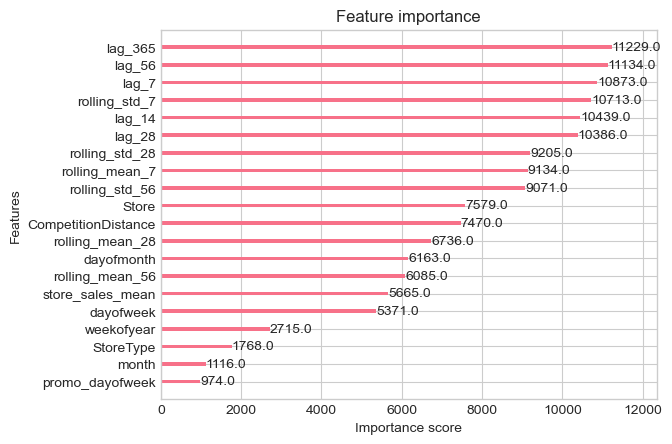

In [1341]:
xgb.plot_importance(model, max_num_features=20)

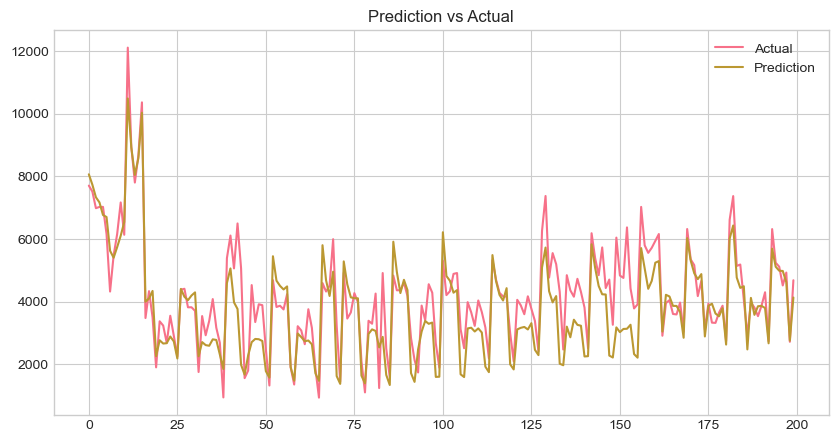

In [1343]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(np.expm1(y_valid).values[:200], label="Actual")
plt.plot(np.expm1(valid_pred)[:200], label="Prediction")

plt.legend()
plt.title("Prediction vs Actual")
plt.show()

Nhìn biểu đồ:

trend → model bắt được

seasonality → bắt được

spike → miss

Đây là pattern cực phổ biến của:

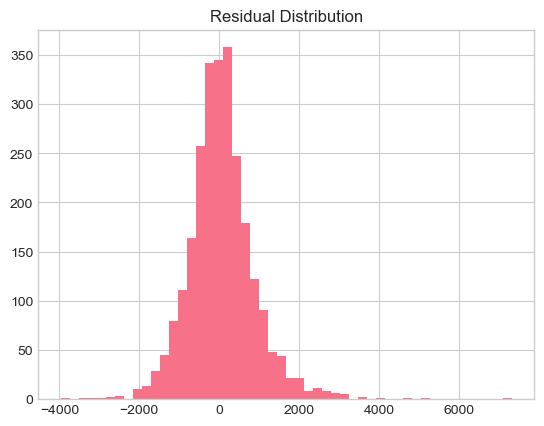

In [1346]:
residuals = np.expm1(y_valid) - np.expm1(valid_pred)

plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.show()

-> một số ngày model miss khá mạnh

### Điều chỉnh thông qua Store-level Target Normalization

In [1350]:
df["sales_norm"] = df["Sales"] / df["store_sales_mean"]
df["sales_norm_log"] = np.log1p(df["sales_norm"])

In [1352]:
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
valid = df.iloc[split_index:]

In [1354]:
X_train = train[features]
y_train = train["sales_norm_log"]

X_valid = valid[features]
y_valid = valid["sales_norm_log"]

In [1356]:
print("sales_norm_log" in train.columns)
print("sales_norm_log" in valid.columns)

True
True


In [1358]:
model.fit(

    X_train,
    y_train,

    eval_set=[(X_valid, y_valid)],

    verbose=100,


)

[0]	validation_0-rmse:0.13526
[100]	validation_0-rmse:0.06512
[200]	validation_0-rmse:0.06429
[300]	validation_0-rmse:0.06411
[400]	validation_0-rmse:0.06398
[500]	validation_0-rmse:0.06413
[600]	validation_0-rmse:0.06424
[700]	validation_0-rmse:0.06441
[800]	validation_0-rmse:0.06452
[900]	validation_0-rmse:0.06461
[1000]	validation_0-rmse:0.06464
[1100]	validation_0-rmse:0.06477
[1200]	validation_0-rmse:0.06484
[1300]	validation_0-rmse:0.06487
[1400]	validation_0-rmse:0.06490
[1500]	validation_0-rmse:0.06494
[1600]	validation_0-rmse:0.06495
[1700]	validation_0-rmse:0.06500
[1800]	validation_0-rmse:0.06504
[1900]	validation_0-rmse:0.06506
[1999]	validation_0-rmse:0.06513


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [1360]:
valid_pred = model.predict(X_valid)

In [1362]:
pred_norm = np.expm1(valid_pred)

pred_sales = pred_norm * valid["store_sales_mean"].values

In [1364]:
score = rmspe(y_valid, valid_pred)

print("Validation RMSPE:", score)

Validation RMSPE: 0.14338024318191198


***Chốt sổ RMSPE: 0.143***

### Giải thích mô hình và đánh giá hiệu năng

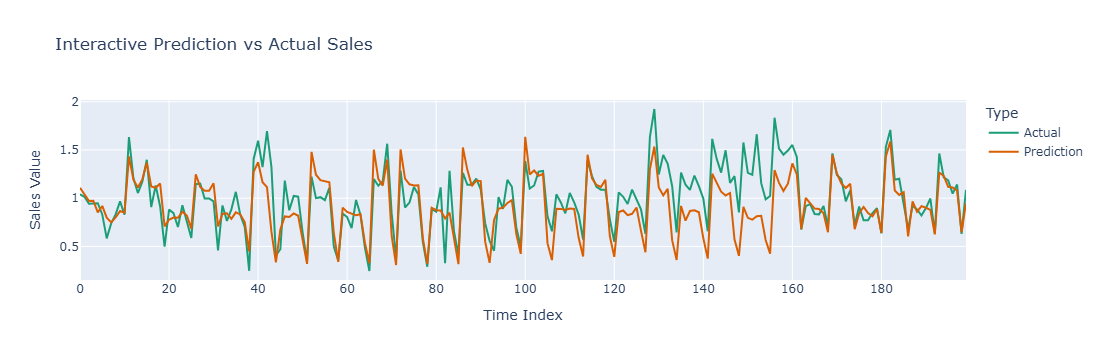

In [1445]:

import plotly.express as px
import pandas as pd
import numpy as np

df_plot = pd.DataFrame({
    'Time_Index': list(range(200)),
    'Actual': np.expm1(y_valid).values[:200].flatten(),
    'Prediction': np.expm1(valid_pred)[:200].flatten()
})


fig = px.line(df_plot, x='Time_Index', y=['Actual', 'Prediction'],
              title='Interactive Prediction vs Actual Sales',
              labels={'Time_Index': 'Time Index', 'value': 'Sales Value'},
              color_discrete_sequence=px.colors.qualitative.Dark2) # chọn palette màu đậm


fig.update_layout(
    xaxis_title="Time Index",
    yaxis_title="Sales Value",
    legend_title="Type",
    font=dict(size=12),
    hovermode="x unified" # rất quan trọng: khi rê chuột hiện cả 2 giá trị cùng lúc
)

fig.show() # In Jupyter, lệnh này hiện biểu đồ tương tác

In [1393]:
import shap


In [1412]:
# 1. Lấy ra một tập mẫu nhỏ (ví dụ 100 dòng ngẫu nhiên)
X_valid_sample = shap.sample(X_valid, 300)

explainer = shap.Explainer(model.predict, X_valid_sample)


shap_values = explainer(X_valid_sample)

PermutationExplainer explainer: 301it [01:28,  2.99it/s]                                                               


C:\Users\Msi\AppData\Local\Temp\ipykernel_8184\975966242.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_valid_sample)


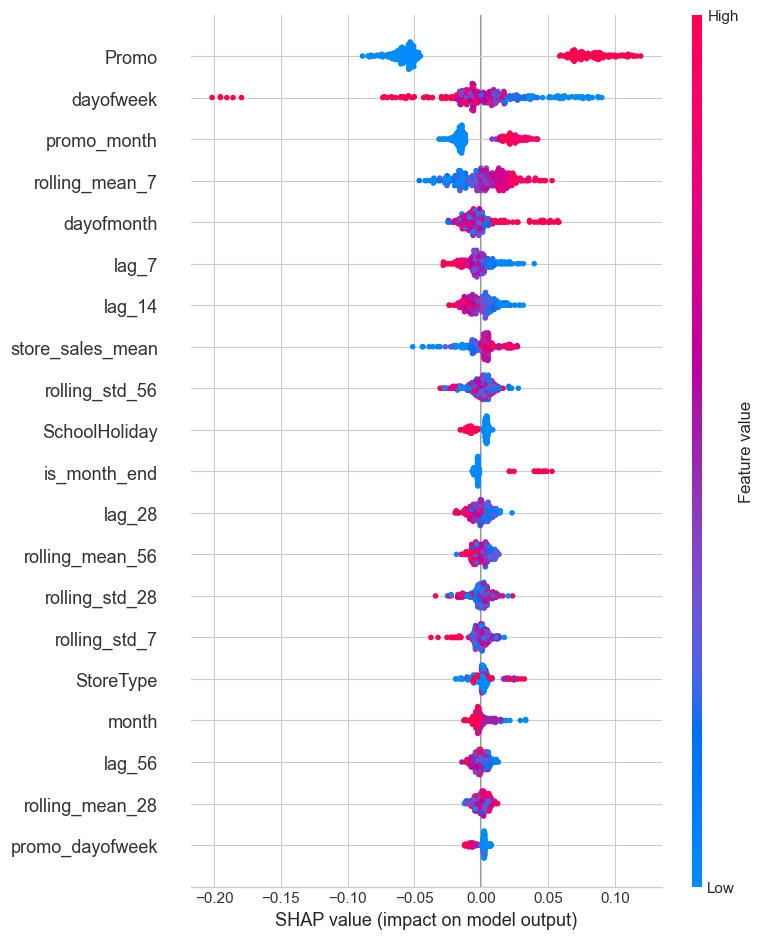

In [1415]:
shap.summary_plot(shap_values, X_valid_sample)

Phân tích chi tiết "Insight" từ mô hình:

Promo (Khuyến mãi) - Yếu tố quyết định sống còn:
Dòng trên cùng cho thấy phân cực rất rõ ràng. Các chấm ĐỎ (Có Promo) tụ lại hẳn sang bên phải, nghĩa là mô hình học được rằng: Cứ có khuyến mãi là doanh số sẽ tăng mạnh. Ngược lại, cụm chấm XANH (Không có Promo) nằm bên trái, kéo doanh số xuống dưới mức trung bình.

dayofweek (Ngày trong tuần) - Kẻ mang nhiều ẩn số:
Biến này đứng top 2 nhưng có phân phối cực kỳ thú vị. Bạn hãy nhìn vào nhóm chấm ĐỎ rực nằm tít ngoài cùng bên trái (quanh mốc -0.20). Màu đỏ tức là giá trị ngày trong tuần cao (ví dụ ngày thứ 6, thứ 7 hoặc Chủ Nhật). Việc nó nằm xa tít bên trái chứng tỏ: Có những ngày cuối tuần kéo tụt thê thảm doanh số (rất có thể cửa hàng đóng cửa vào Chủ Nhật ở tập dữ liệu này).

Các biến thời điểm (promo_month, is_month_end):
Các biến này cũng theo quy luật: Chấm đỏ nằm bên phải. Có nghĩa là mô hình sẽ tự động cộng thêm điểm vào kết quả dự báo nếu hôm đó rơi vào tháng có đợt promo hoặc là ngày cuối tháng.

Nhóm biến quá khứ / Time-series (rolling_mean_7, lag_14, lag_7):
Đây là đặc trưng của bài toán Time Series. Chấm đỏ chủ yếu nằm bên phải (dù lực kéo không mạnh bằng Promo). Tức là nếu tuần trước hoặc 14 ngày trước bán đắt hàng (màu đỏ), thì theo quán tính, mô hình cũng dự báo hôm nay sẽ bán tốt hơn.

Nhóm biến ít ảnh hưởng (Từ giữa trở xuống dưới):
Các biến như StoreType, SchoolHoliday, hay CompetitionDistance các chấm xanh đỏ rải khá lộn xộn, co cụm sát vào trục 0. Tức là mô hình không dựa dẫm nhiều vào các biến này để đưa ra quyết định tăng/giảm dự báo.

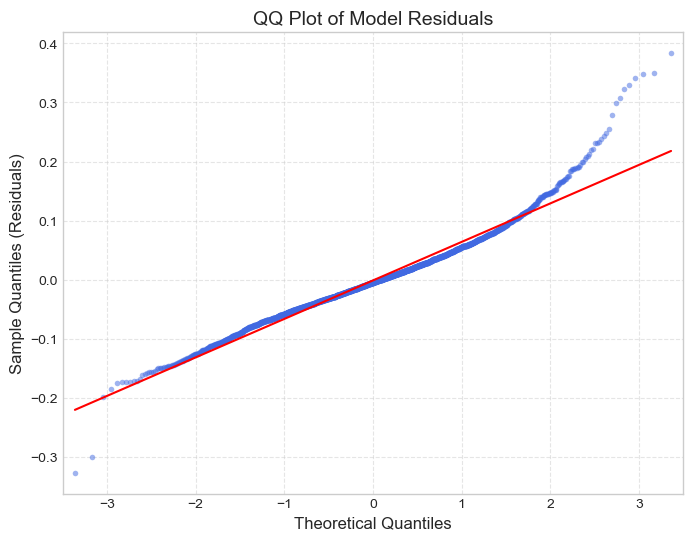

In [1451]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np


residuals = y_valid - valid_pred

fig, ax = plt.subplots(figsize=(8, 6))


sm.qqplot(
    residuals, 
    line='s', 
    ax=ax, 
    marker='o', 
    markersize=4,                 
    markerfacecolor='royalblue',  
    markeredgecolor='none',       
    alpha=0.5                     
)

plt.title("QQ Plot of Model Residuals", fontsize=14)
plt.xlabel("Theoretical Quantiles", fontsize=12)
plt.ylabel("Sample Quantiles (Residuals)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Phân tích các phần của biểu đồ:

Phần khúc giữa (Bám sát đường đỏ): Từ khoảng -2 đến 1 trên trục hoành, các chấm của bạn bám rất khít vào đường chéo màu đỏ.

->Ý nghĩa: Đối với những ngày bán hàng bình thường (không có đột biến), mô hình của bạn dự báo cực kỳ chính xác. Sai số phân phối ngẫu nhiên và rất chuẩn.

Cái đuôi bên phải vểnh vọt lên trên (Lỗi nặng nhất): Từ mốc 1.5 trở đi, các chấm bay vút lên trên không thèm bám theo đường đỏ nữa.

-> Ý nghĩa: Phần dư = Thực tế - Dự báo. Việc chấm nằm vọt lên trên (phần dư dương lớn) có nghĩa là số liệu Thực tế cao hơn rất nhiều so với mức Dự báo.

-> Kết luận: Mô hình của bạn đang bị bảo thủ (under-predicting) ở những ngày có doanh số bùng nổ. Khi có những ngày "đỉnh" doanh thu, mô hình không dám dự báo một con số quá cao, dẫn đến sai số ở các ngày này rất lớn.

Cái đuôi bên trái hơi rớt xuống: Có vài chấm ở tít góc dưới cùng bên trái cắm xuống dưới đường đỏ.

-> Ý nghĩa: Ở một vài ngày bán cực kỳ ế ẩm, mô hình lại hơi "lạc quan" dự báo cao hơn thực tế một chút (phần dư âm lớn). Tuy nhiên, lỗi này khá nhỏ so với đuôi bên phải.

# ***Đánh giá tổng quan các mô hình***

Trong bài toán dự báo doanh thu chuỗi thời gian cho hệ thống bán lẻ đa cửa hàng, ba phương pháp mô hình hóa đã được triển khai nhằm phục vụ các mục tiêu khác nhau: mô hình tuyến tính cơ sở (Ridge Regression), mô hình phân rã chuỗi thời gian (Facebook Prophet) và mô hình học máy phi tuyến (XGBoost). Việc kết hợp các phương pháp này cho phép đánh giá toàn diện từ góc độ độ chính xác dự báo đến khả năng giải thích và hiểu hành vi dữ liệu.

**So sánh định lượng**

Kết quả đánh giá trên tập validation sử dụng chỉ số RMSPE cho thấy sự khác biệt rõ rệt về hiệu năng giữa các mô hình. Ridge Regression đạt mức RMSPE khoảng 0.164, đóng vai trò là baseline ổn định. Prophet cho kết quả không đồng đều giữa các cửa hàng, với sai số dao động lớn (từ khoảng 0.29 đến trên 1.8), phản ánh hạn chế trong việc tổng quát hóa. Trong khi đó, XGBoost đạt hiệu năng tốt nhất với RMSPE giảm xuống khoảng 0.143 sau khi áp dụng các kỹ thuật feature engineering và chuẩn hóa theo cửa hàng.

**Phân tích mô hình Ridge Regression**

Ridge Regression đóng vai trò là mô hình cơ sở với ưu điểm về tính đơn giản và khả năng kiểm soát tốt overfitting. Mô hình hoạt động hiệu quả khi sử dụng các đặc trưng tuyến tính như lag và trend, đồng thời cho kết quả ổn định giữa tập huấn luyện và validation. Tuy nhiên, do bản chất tuyến tính, Ridge không thể mô hình hóa các quan hệ phi tuyến và gặp khó khăn trong việc nắm bắt các biến động mạnh như các đỉnh doanh thu trong thời gian khuyến mãi.

**Phân tích mô hình Facebook Prophet**

Facebook Prophet được sử dụng nhằm phân tích sâu từng cửa hàng thông qua việc phân rã chuỗi thời gian thành các thành phần như xu hướng (trend), mùa vụ (seasonality) và tác động của biến ngoại sinh (promotion). Mô hình này thể hiện rõ ưu thế về khả năng giải thích, giúp phát hiện các quy luật như chu kỳ theo tuần và ảnh hưởng của chương trình khuyến mãi.

Tuy nhiên, Prophet bộc lộ hạn chế khi áp dụng cho bài toán đa cửa hàng, đặc biệt với các cửa hàng có hành vi doanh thu biến động mạnh. Kết quả không ổn định giữa các cửa hàng cho thấy mô hình khó thích nghi với sự khác biệt về phân khúc và đặc điểm kinh doanh.

**Phân tích mô hình XGBoost**

XGBoost là mô hình có hiệu năng dự báo cao nhất trong ba phương pháp. Nhờ khả năng học các quan hệ phi tuyến và tận dụng hiệu quả các đặc trưng được thiết kế (bao gồm lag, rolling statistics và các biến thời gian), mô hình này cải thiện đáng kể độ chính xác dự báo.

Phân tích SHAP cho thấy các yếu tố quan trọng nhất bao gồm chương trình khuyến mãi (Promo), đặc trưng theo ngày trong tuần (dayofweek) và các chỉ số động lượng ngắn hạn (rolling mean, lag 7–14). Điều này cho thấy mô hình dựa nhiều vào thông tin ngắn hạn và hành vi lặp lại theo tuần để đưa ra dự báo.

Tuy nhiên, phân tích residual và QQ plot cho thấy mô hình vẫn gặp khó khăn trong việc dự báo các giá trị cực trị, đặc biệt là các đỉnh doanh thu cao. Điều này cho thấy XGBoost có xu hướng đánh giá thấp các sự kiện bán hàng đột biến, nhiều khả năng do ảnh hưởng của phép biến đổi log và sự thiếu hụt các đặc trưng tương tác mạnh.

So sánh tổng thể

**Xét trên ba khía cạnh chính:**

Độ chính xác dự báo: XGBoost vượt trội so với Ridge và Prophet

Khả năng giải thích: Prophet thể hiện rõ ràng nhất, tiếp theo là Ridge

Tính ổn định: Ridge ổn định nhất, trong khi Prophet biến động mạnh

Không có mô hình nào tối ưu trên mọi phương diện. Ridge phù hợp làm baseline, Prophet phù hợp cho phân tích hành vi, trong khi XGBoost là lựa chọn tốt nhất cho mục tiêu dự báo.

***Kết luận***

Kết quả so sánh cho thấy bài toán dự báo doanh thu bán lẻ mang tính phi tuyến và phụ thuộc mạnh vào các yếu tố ngắn hạn. Do đó, các mô hình tuyến tính như Ridge chỉ đóng vai trò tham chiếu, trong khi các mô hình học máy như XGBoost là cần thiết để đạt hiệu năng cao.

Mô hình XGBoost được lựa chọn làm mô hình chính cho hệ thống dự báo nhờ khả năng tận dụng hiệu quả các đặc trưng thời gian và cải thiện đáng kể sai số dự báo. Trong khi đó, Prophet đóng vai trò hỗ trợ phân tích và giải thích, giúp cung cấp góc nhìn về hành vi và mùa vụ trong dữ liệu.